# Generic Mappping Tools (GMT) 

**GMT** is an open-source tool for geographic data manipulating/processing (*i.e.*, filter time series, trend fit, resampling, data projection) and producing high-quality figures. It is widely used across Earth, Ocean, and Planetary sciences. 

<img src="https://www.generic-mapping-tools.org/_static/figures/lithospheric-age.png" width="500" height="300" />

GMT was originally developed for UNIX and Windows command lines. More recently, it has been rebuilt as an Application Programming Interface (API) and can now be accessed via wrapper libraries from MATLAB/Octave, Julia, and Python (`PyGMT`).

# 0. Objectives

* Use **pyGMT** to make high-quality maps/plots related with Geotechincal Earthquake Engineering
* Utilize the **USGS ComCat** database to retrieve information about specific seismic events
* Manipulate and visualize netCDF, JSON, and XML file formats using PyGMT scripts
* Utilize focal mechanism data to plot beachballs and interpret their meaning

# 1. Installing GMT and pygmt

GMT is available on Windows, macOS, and Linux. The fastest way to install GMT and its Python pakcage `PyGMT` is creating a virtual environment with **conda**:

<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">conda create --name pygmt --channel conda-forge python=3.13 pygmt --yes</code><br>
    <code style="color: #212121;">conda activate pygmt</code>
  </div>
</div>

If you are using a `virtual environment` (`./.venv`) you can use: 

<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">conda create --prefix ./.venv --channel conda-forge python=3.13 pygmt --yes</code><br>
    <code style="color: #212121;">conda activate ./.venv</code><br>
    <code style="color: #212121;">conda install ipykernel</code>
  </div>
</div>

More details about installation can be found at https://www.pygmt.org/dev/install.html#

After the installation, we can import the `PyGMT` package and check its version:

In [24]:
import pygmt
import pandas as pd
pygmt.show_versions()

PyGMT information:
  version: v0.19.0
System information:
  python: 3.12.12 | packaged by conda-forge | (main, Oct 13 2025, 14:47:45) [Clang 19.1.7 ]
  executable: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/1_GMT/env/bin/python
  machine: macOS-26.6.2-arm64-arm-64bit
Dependency information:
  numpy: 2.5.1
  pandas: 3.0.3
  xarray: 2026.7.0
  packaging: 26.0
  contextily: 1.7.1
  geopandas: 1.1.4
  IPython: 9.15.0
  pyarrow: None
  rioxarray: 0.23.0
  gdal: 3.11.5
  ghostscript: 10.07.1
GMT library information:
  version: 6.6.0
  padding: 2
  share dir: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/1_GMT/env/share/gmt
  plugin dir: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/1_GMT/env/lib/gmt/plugins
  library path: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/1_GMT/env/lib/libgmt.dylib
  cores: 10
  grid layout: rows
  image layout: 
  binary version: 6.6.0


# 2. Simple examples

All the plots are handled by the `pygmt.Figure()` class, which works as a blank canvas:

In [25]:
fig = pygmt.Figure()

GMT/PyGMT uses layers, so each new element is stacked on top of previous ones. We will learn its basic capabilities by working with some simple examples.

<div class="alert alert-block alert-danger">
<b>Warning:</b> You cannot directly clear or reset a figure object after it has been created. Instead, you should create a new <b>pygmt.Figure</b> object every time you want to start a fresh map or plot.
</div>

## 2.1. Coastlines, borders, frames, ticks and titles: CEUS coastline

Before plotting, it is necessary to define:

 - `region`: Geographic bounding box specified as a list of `[xmin, xmax, ymin, ymax]`, *e.g.*, ```[-95, -75, 25, 41]```. Note: To specify a *global* domain, use `region = "g"` 
 - `projection`: GMT supports [33 types of projections](https://www.pygmt.org/v0.13.0/projections/index.html#cylindric-projections), from non-geographic (*i.e.,* cartesian, polar, logarithmic) to arbitrary perspectives. The projection is specified by a **one-letter code**, longitude, latitude, and width, *e.g.*, to define a [Transverse Mercator](https://www.pygmt.org/v0.13.0/projections/cyl/cyl_transverse_mercator.html#sphx-glr-projections-cyl-cyl-transverse-mercator-py) projection centered at **lon = 85W, lat = 33N, and 10 cm width**: `T-85/33/10c`. Map height is determined based on the region and projection.

We can add the region's coastlines and borders using the `fig.coast()` method. Its main attributes are:

- `water`: Set water color 
- `land`: Set land color
- `borders`: Draws political boundaries with a format *border/pen*:
    - border: *1 - National*, *2 - State*, *3 - Marine*, *a - All boundaries*
    - pen: format = "Point,Color,type". Default option is "0.25p,black,solid"

    *e.g.*, `1/0.5p,red,dashed` for drawing **national boundaries with a 0.5-point dashed red pen** 

GMT supports several [color systems](https://docs.generic-mapping-tools.org/6.0/cookbook/colorspace.html), including HEX Codes (*e.g.,* #FF5733), RGB (*e.g.,* 255/0/0), and over [600 unique color names](https://docs.generic-mapping-tools.org/latest/_images/GMT_RGBchart.png) (*e.g.,* lightblue)

We can add frames and thicks to the map with the `frame` attribute. In this case, we have to define:

- `Axis labels`: Using the formats `WSne` or `lbtr`. The axes are named as West/west/left (**W, w, l**), South/south/bottom (**S, s, b**), North/north/top (**N, n, t**), and East/east/right (**E, e, r**). Upper-case letters of cardinal directions (W, S, N, E) indicate thick marks and annotations, whereas lower-case letters (w, s, n, e) indicate only axes with tick marks. The other letters (l, b, t, r) are used only to plot the axis.

- `Frame`: Defines the grid line (**g**), ticks (**f**) lines, and annotations (**a**) distance, *i.e.*, `a10f5g2.5` will create a *frame with distances of 2.5°, 5°, and 10° for gridlines, marks, and annotations, respectively.*.

A tutorial for frame and axes attributes is available at https://www.pygmt.org/dev/tutorials/basics/frames.html. More details about `frames` can be found at https://docs.generic-mapping-tools.org/6.6/gmt.html#b-full.


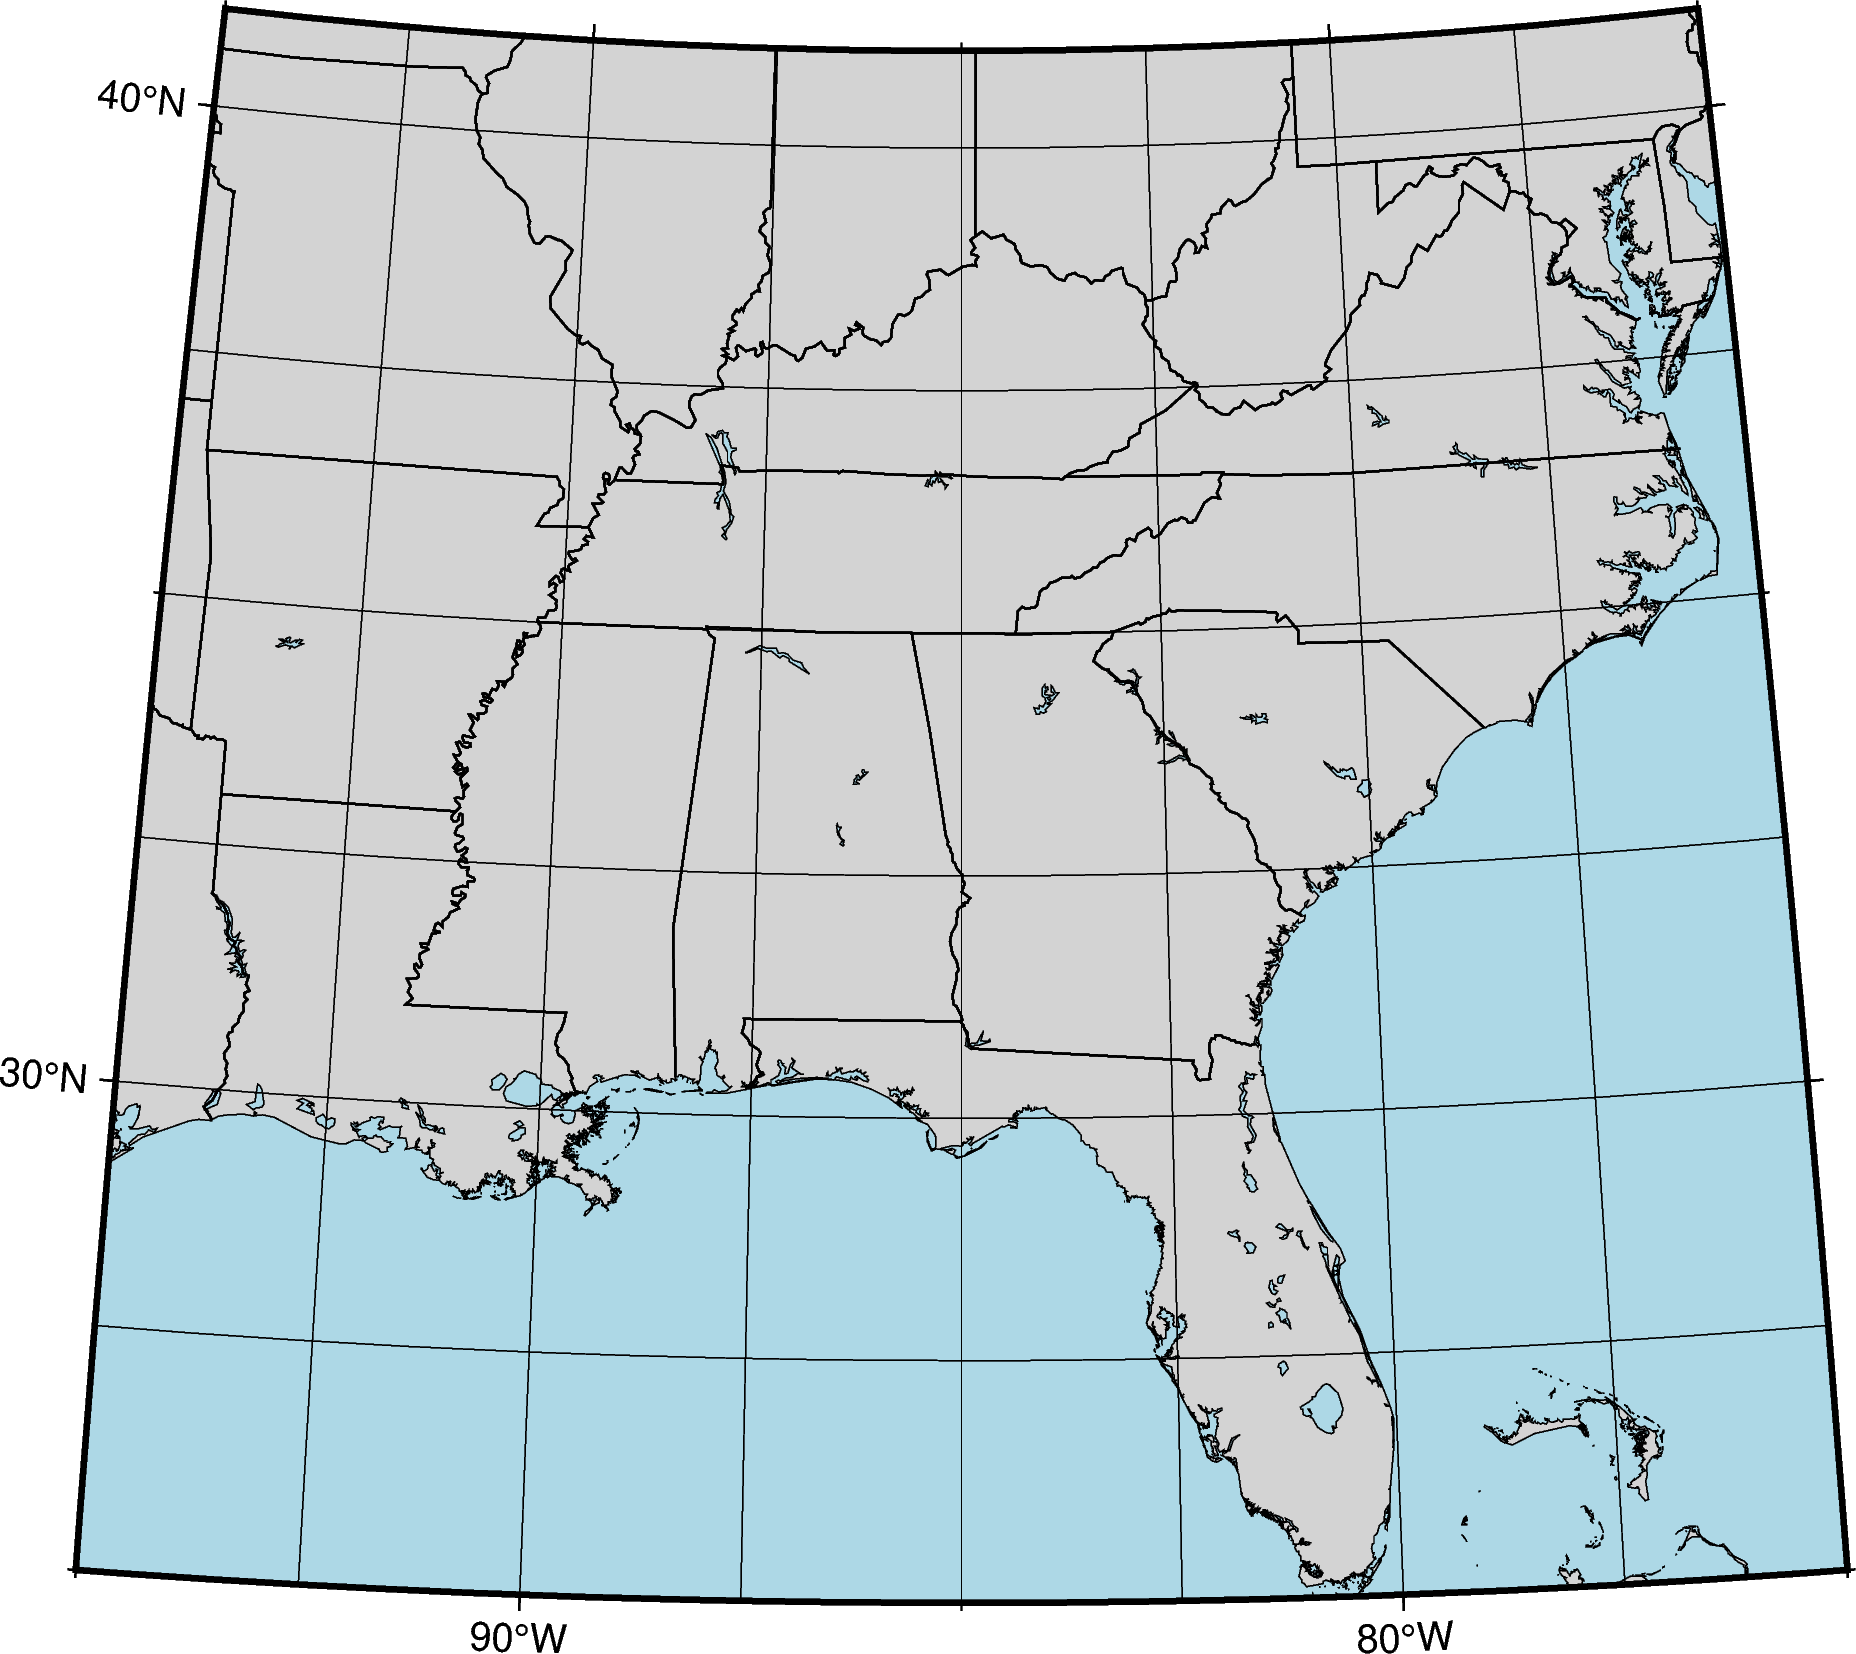

In [26]:
region = [-95, -75, 25, 41]

fig.coast(region=region, 
          projection="T-85/33/15c", 
          water="lightblue", 
          land="lightgrey", 
          borders="2/0.5p,black",
          shorelines=True, 
          frame=["WSne", "a10f5g2.5"])

# To see the figure looks like
fig.show()

Another option is to define the frame and axis using the `fig.basemap()` method. With `fig.basemap()` we can also specify a title of the figure passing a **+t***title* arguments to `frame`:

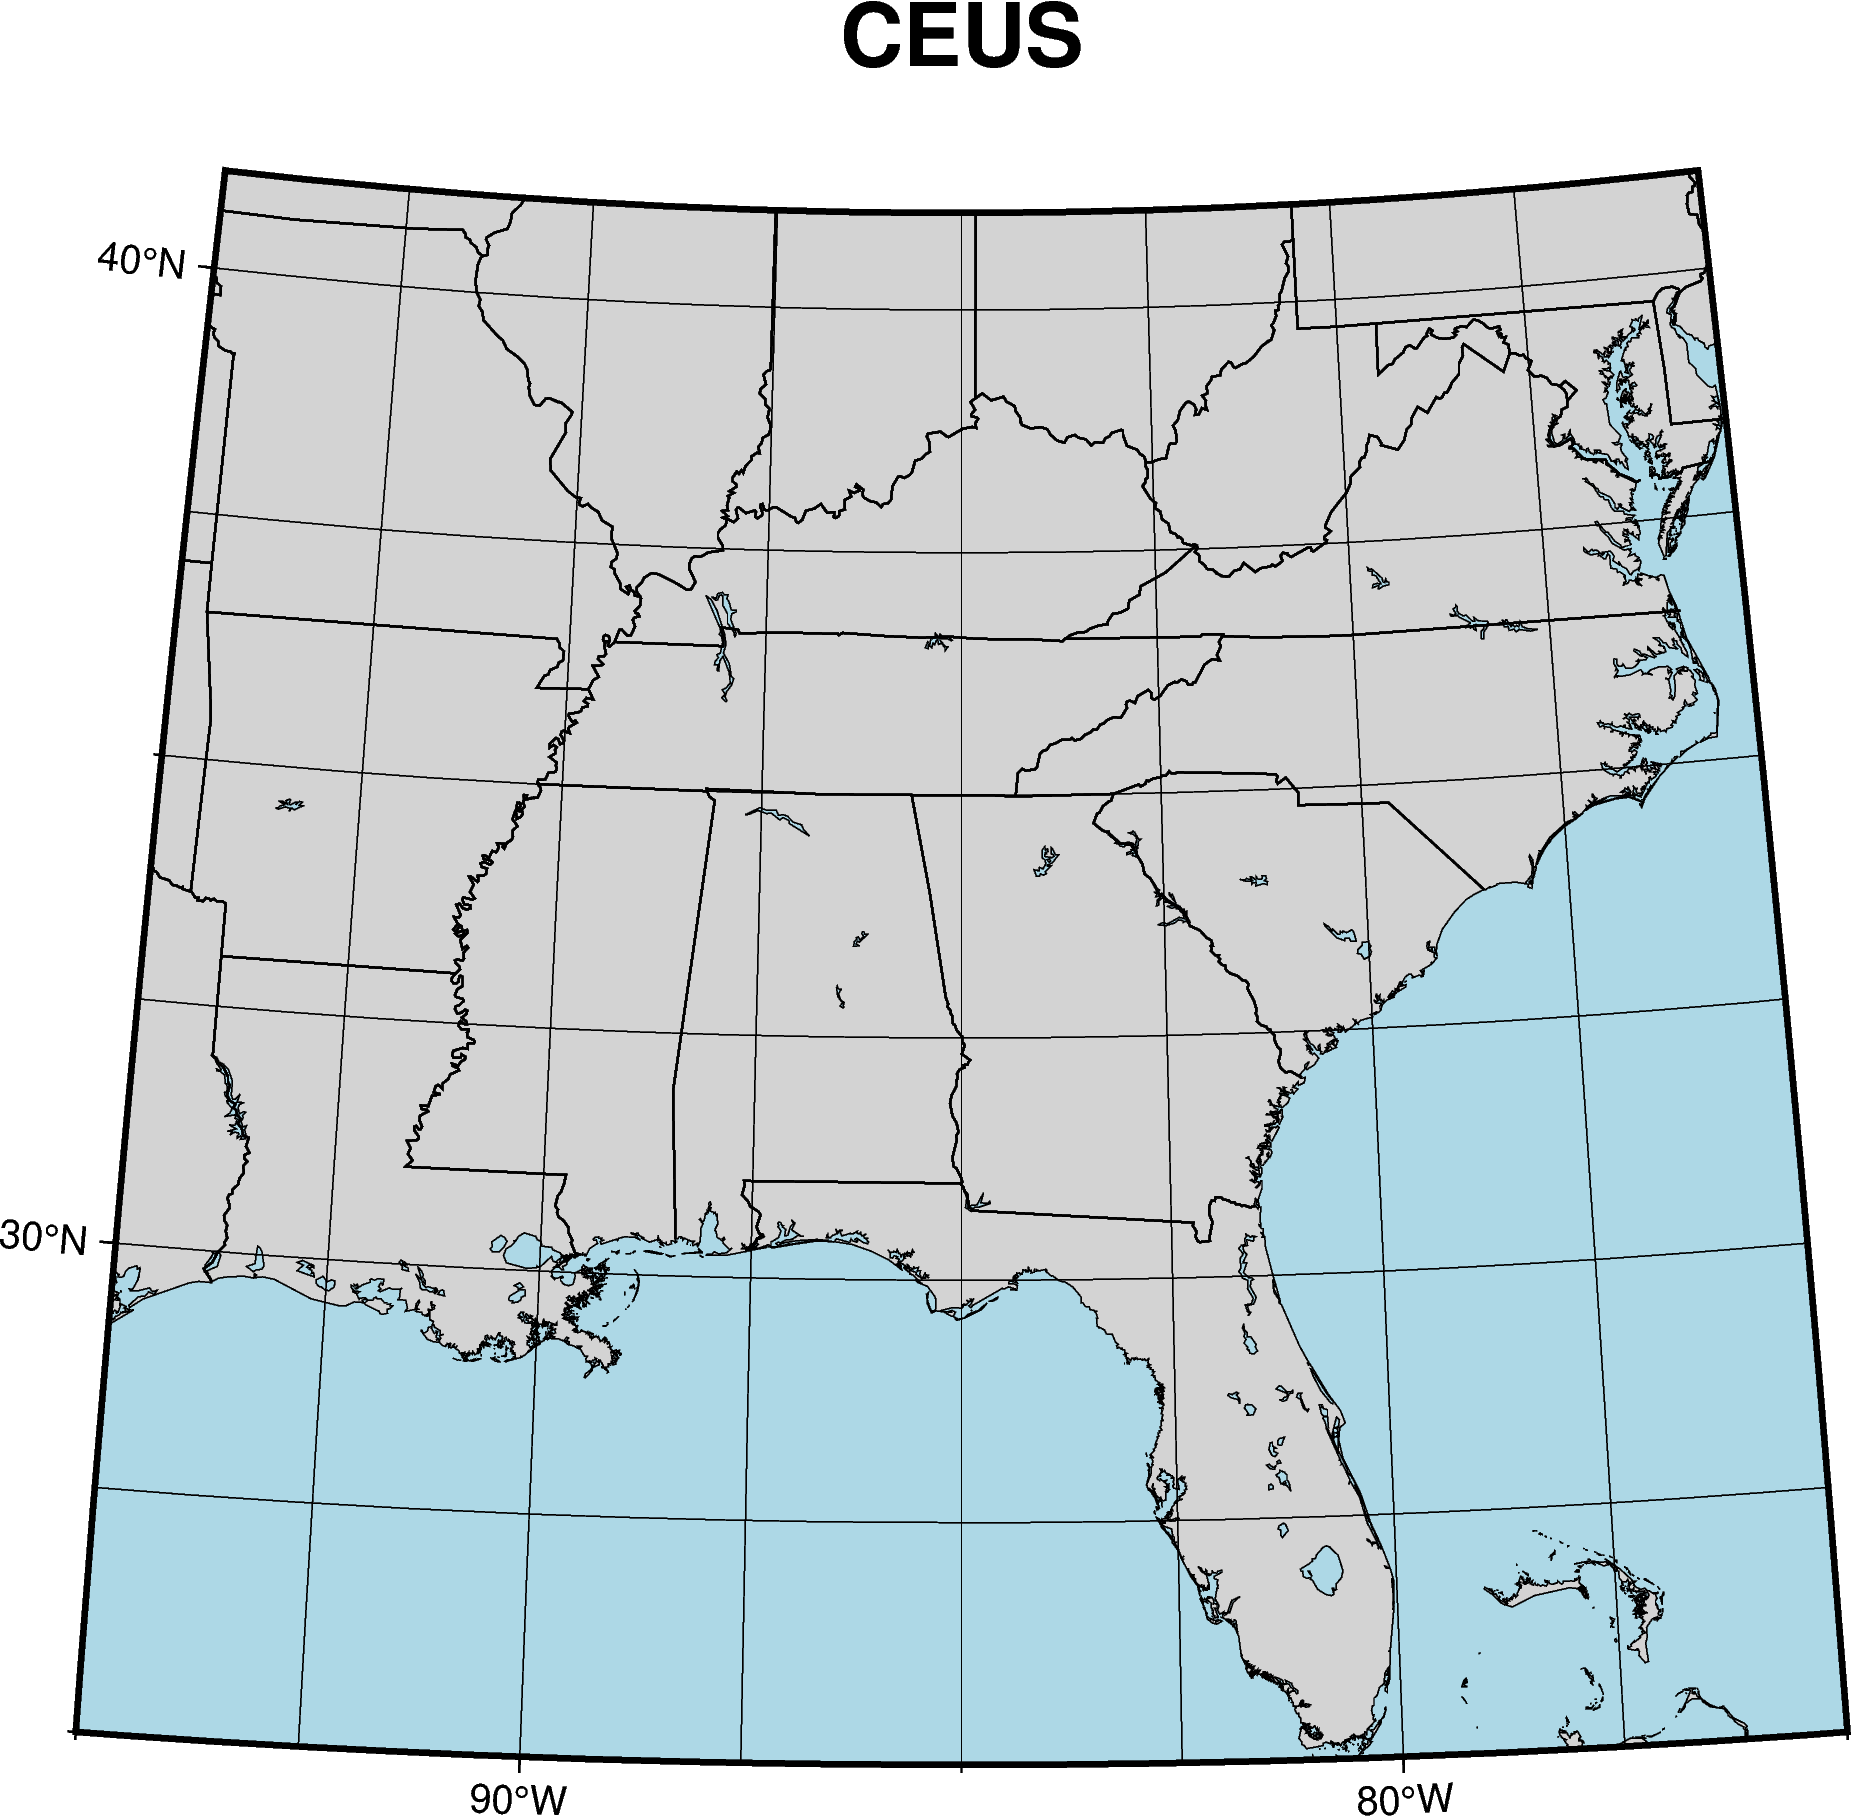

In [27]:
fig2 = pygmt.Figure()
fig2.coast(region=region, 
           projection="T-85/33/15c", 
           water="lightblue", 
           land="lightgrey", 
           borders="2/0.5p,black",  
           shorelines=True)

fig2.basemap(frame=[
    "a10f5g2.5", 
    '+tCEUS'
])

fig2.show()

To save the figure we use the `fig.savefig()` method. For **PDF** files:

In [28]:
fig2.savefig(fname="fig/CEUS.pdf")

For raster files, we can define DPI (dots per inch) and other diplay options:


In [29]:
fig2.savefig('fig/CEUS.png',  # Supported formats: jpg, jpeg, tif, tiff, ppm
            transparent=True, # Transparent background (only for png)
            crop=True, # Crop the canvas to the plot area
            dpi=300 
            )

## 2.2. Data points and legends: CEUS earthquakes 

We can plot scatter points, lines, and polygons using the `fig.plot()` method. As an example, we will plot the epicenter of earthquakes $M_w \geq$ 2.5 recorded in CEUS from 2000/01/01 to 2025/12/31. The database is in **data/usgs_quakes_2000_2025.csv**. It comes from [USGS Earthquake Catalog (ComCat)](https://earthquake.usgs.gov/earthquakes/search/). First, the data is loaded as a `pandas.DataFrame`:

In [30]:
data = pd.read_csv("data/usgs_quakes_2000_2025.csv")
data.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-30T21:27:04.700Z,36.174833,-89.381333,6.1100,2.52,md,39.0,52.0,0.04189,0.14,...,2026-04-01T22:48:42.040Z,"12 km WNW of Newbern, Tennessee",earthquake,0.21000,0.550000,0.074220,34.0,reviewed,nm,nm
1,2025-12-28T17:47:09.990Z,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.32,...,2026-04-01T22:48:29.040Z,"11 km ENE of Lancaster, Kentucky",earthquake,0.41000,2.290000,0.022049,12.0,reviewed,se,se
2,2025-12-27T12:47:50.144Z,31.812200,-93.386100,5.0000,2.90,mb_lg,26.0,94.0,0.85600,1.05,...,2026-04-01T22:48:20.040Z,"12 km E of Pleasant Hill, Louisiana",earthquake,3.28000,1.992000,0.154000,11.0,reviewed,us,us
3,2025-12-26T06:06:30.787Z,37.043300,-96.108100,5.0000,2.50,mb_lg,26.0,77.0,0.34700,0.60,...,2026-04-01T22:48:13.040Z,"5 km SSW of Peru, Kansas",earthquake,2.03000,1.303000,0.154000,11.0,reviewed,us,us
4,2025-12-14T10:12:26.824Z,29.074000,-97.829000,6.9835,2.80,ml,9.0,83.0,0.00000,0.10,...,2026-03-10T22:18:41.040Z,"20 km ENE of Falls City, Texas",earthquake,0.67224,0.471662,0.200000,16.0,reviewed,tx,tx


<div class="alert alert-block alert-info">
    <b>Note:</b> pygmt provides different datasets for tests and documentation examples.
    <p style="margin-top: 10px; margin-bottom: 0;">Datasets can be accessed through <b>pygmt.datasets.load_sample_data(name)</b>. To get a list of all available datasets, use <b>pygmt.datasets.list_sample_data</b>.</p>
</div>

We will plot the epicenters as **stars** of different sizes, depending on the magnitude of the earthquakes. To do this, we need to pass the following attributes to the `fig.plot()` method:

- `x`/`y`: An array with longitude and latitude coordinates, respectively
- `style`: Defines the symbol type. GMT supports [14 basic geometric symbols](https://www.pygmt.org/dev/gallery/symbols/basic_symbols.html) using a one-letter shortcut, *e.g.*, `a0.3c` defines a star (**a**) with a size of 0.3 cm. Note: By default, `PyGMT` assumes a **line symbol** connecting each point in the database.
- `pen`: Set characteristics of the symbols/polygons outline
- `fill`: Set color or pattern for filling symbols/polygons

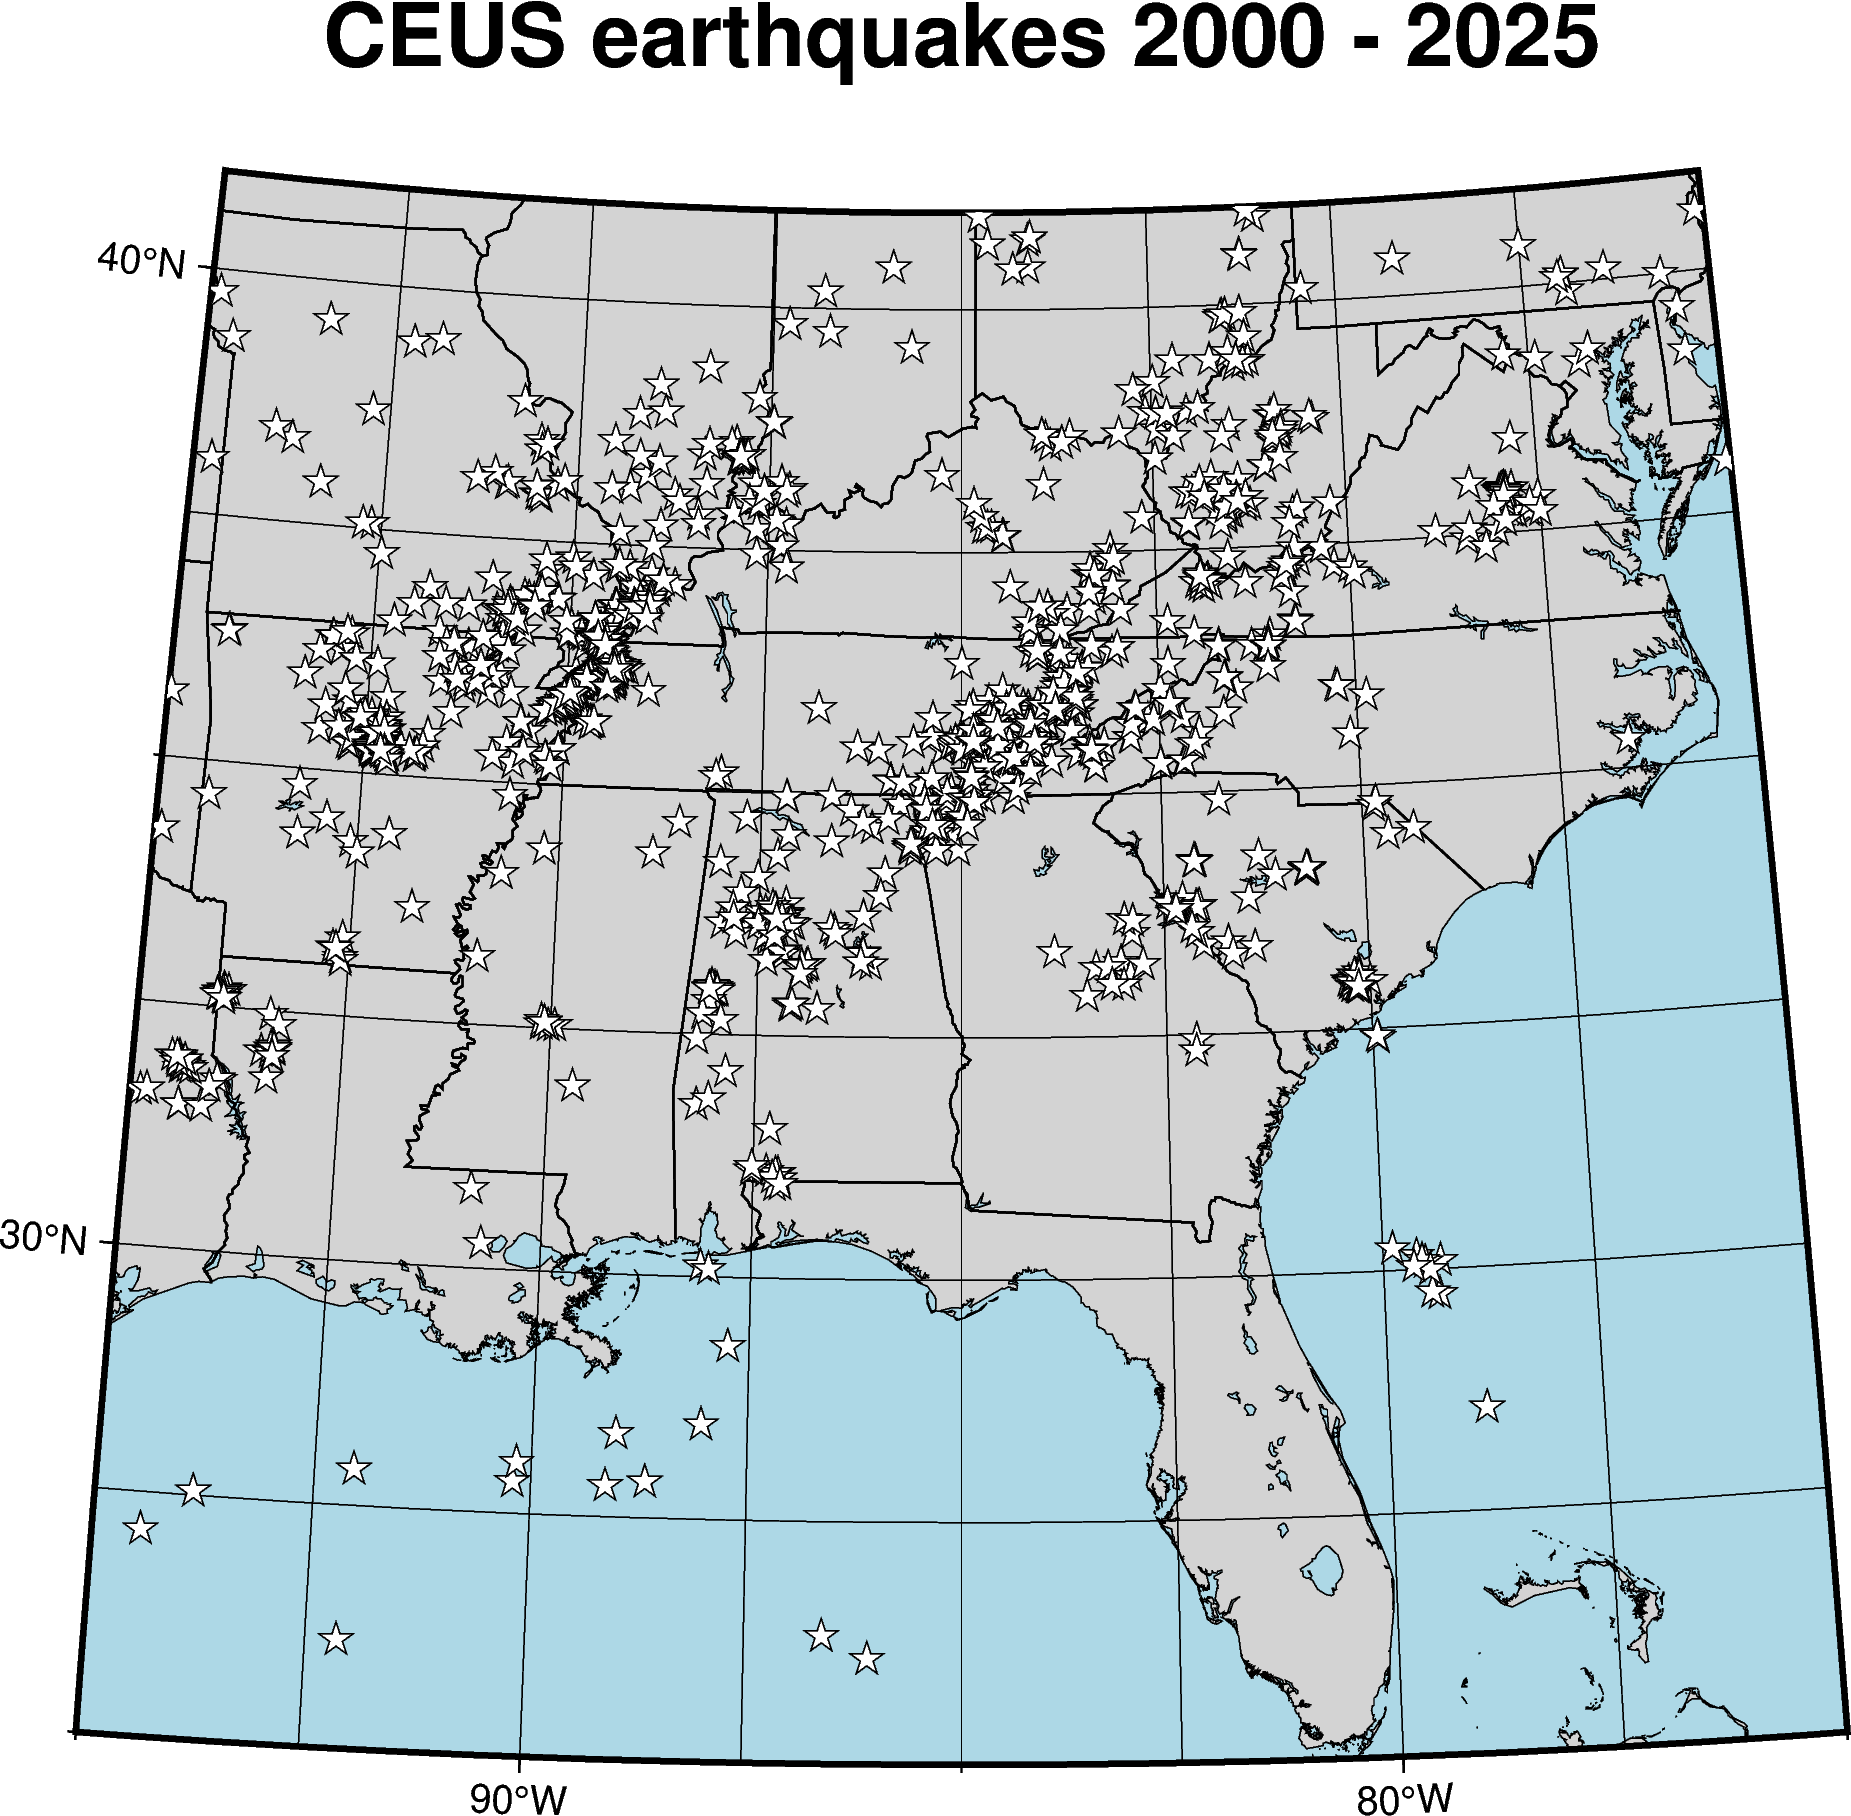

In [31]:
fig3 = pygmt.Figure()
fig3.coast(region=region, projection="T-85/33/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
fig3.basemap(frame=["a10f5g2.5",'+tCEUS earthquakes 2000 - 2025'])

fig3.plot(
    x=data.longitude,
    y=data.latitude,
    style="a0.3c",
    fill="white",
    pen="black",
)

fig3.show()

We can map the size of the symbols to earthquakes’ magnitudes by passing the `size` attribute. Considering that magnitudes are on logartihmic scales, we can define each event size using a power law, *i.e.*, `size` = $2^{M_W}$. In this case, the attribute `style` only requires a one-letter shortcut. To improve readibility, we will use a circle (**c**), instead of stars, to represent the epicenters.

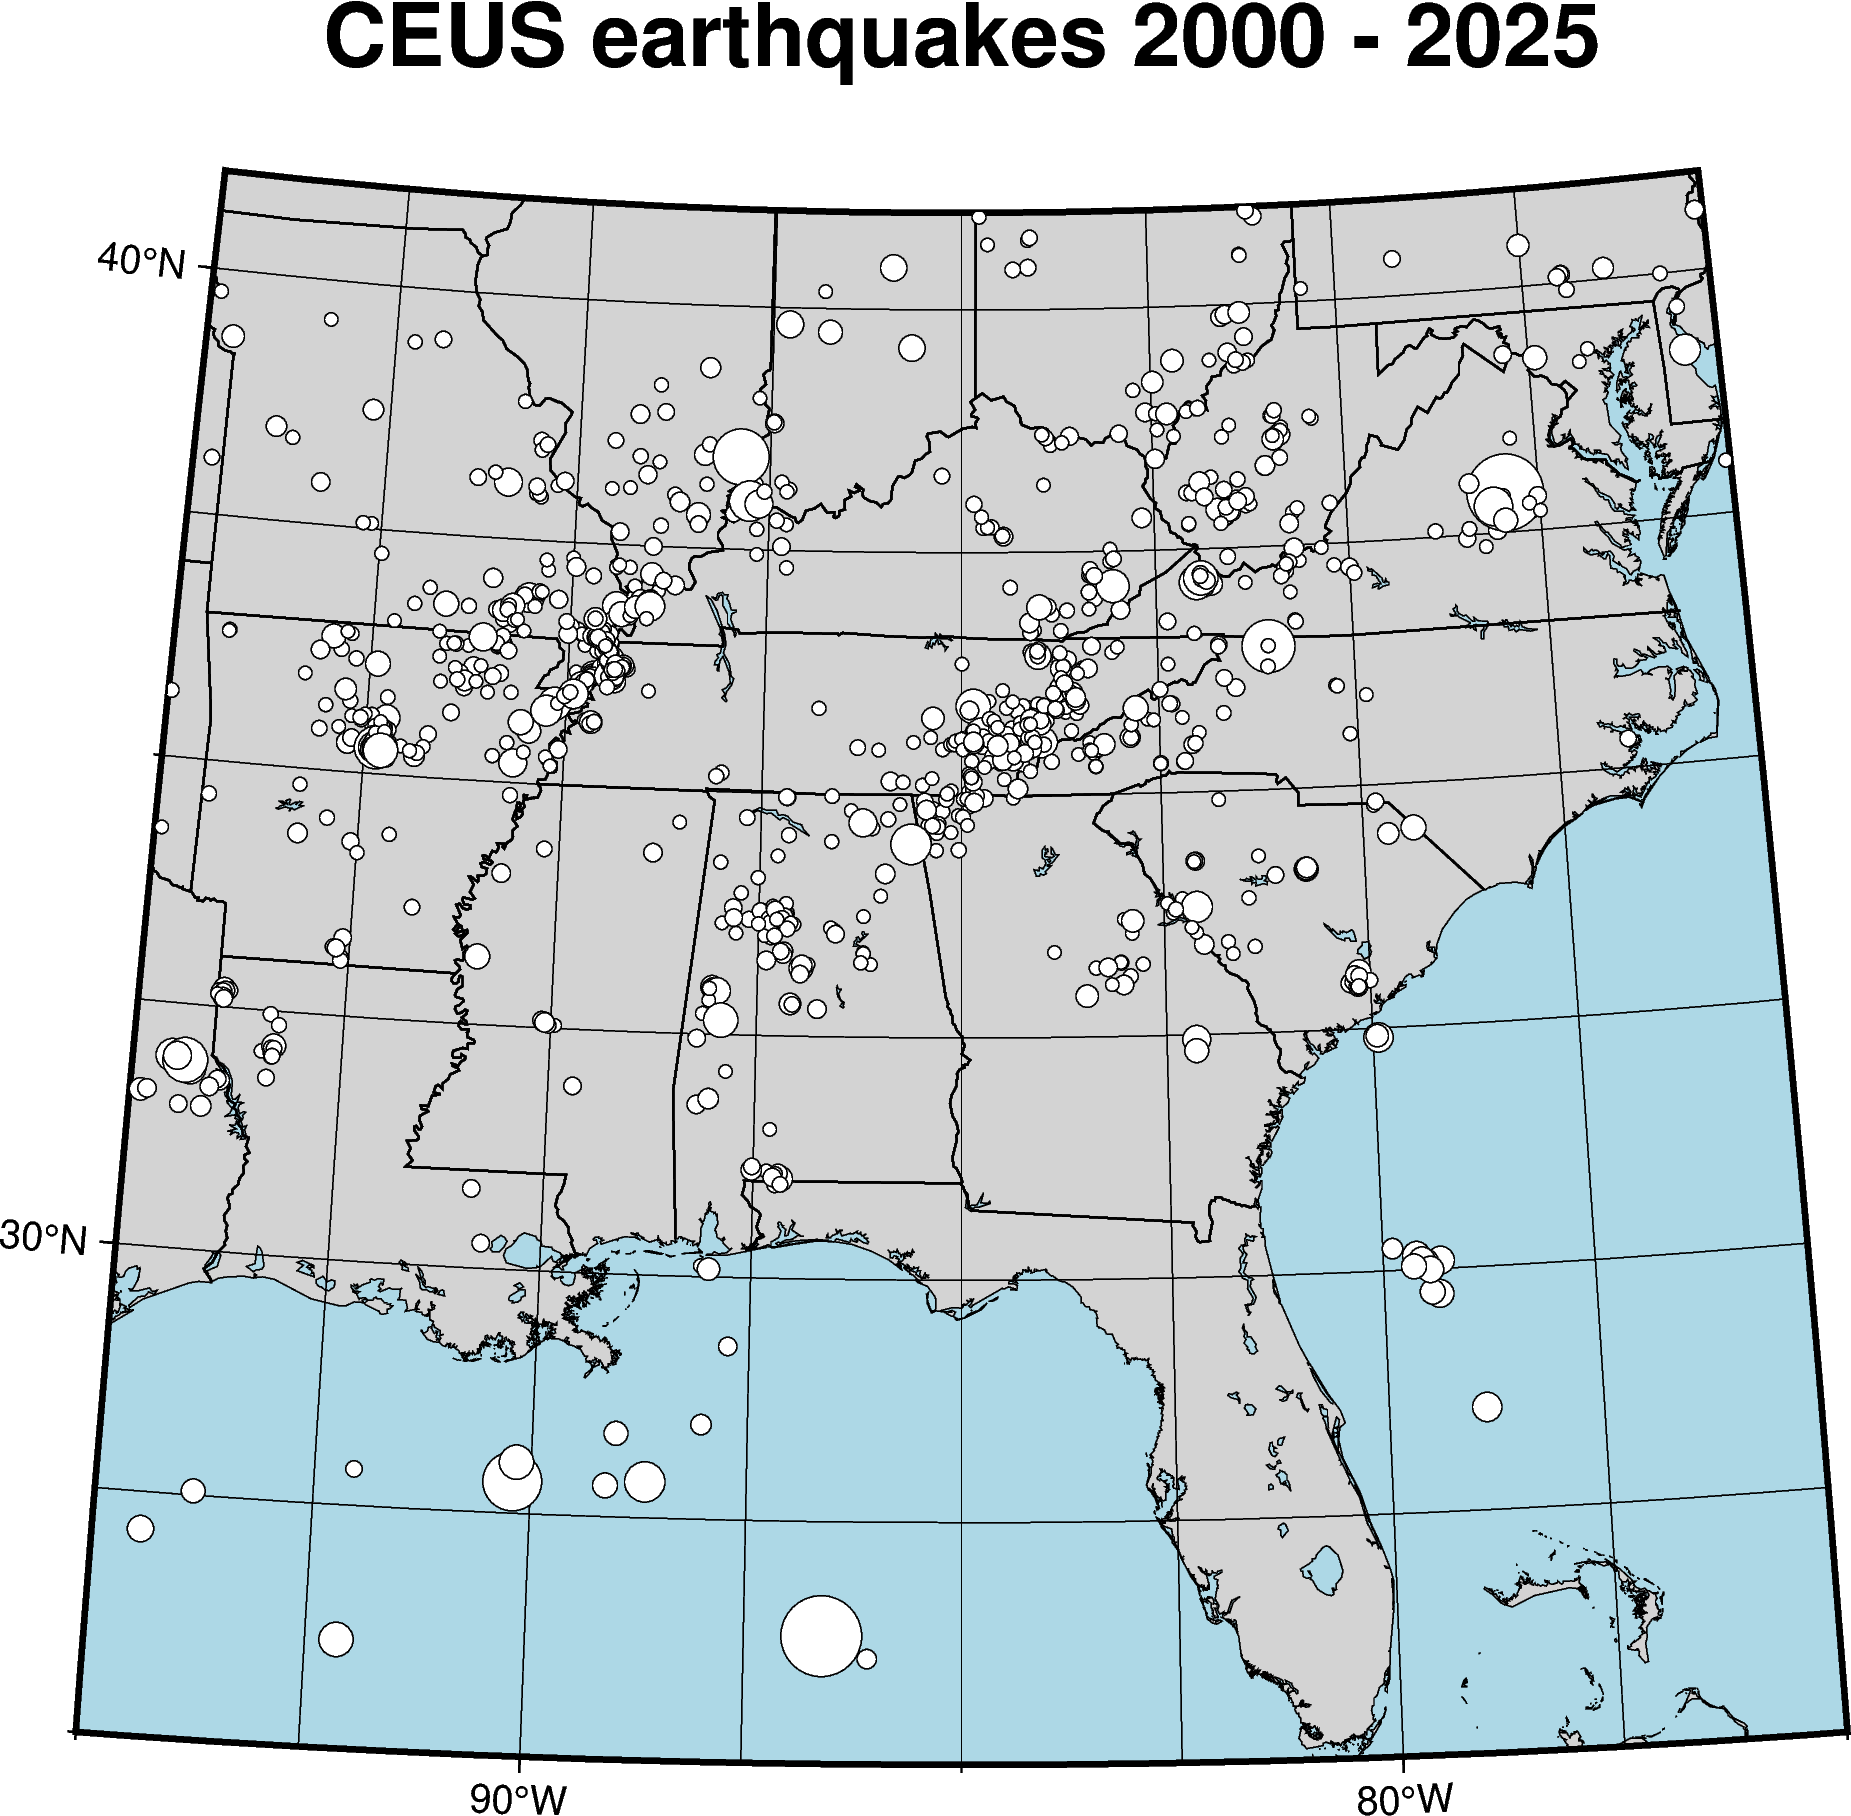

In [32]:
fig3 = pygmt.Figure()
fig3.coast(region=region, projection="T-85/33/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
fig3.basemap(frame=["a10f5g2.5",'+tCEUS earthquakes 2000 - 2025'])

fig3.plot(
    x=data.longitude,
    y=data.latitude,
    size=0.03 * (1.7**data.mag),   ## Power law: The factor 0.03 is a factor scale to keep circles within the map 
    style="c",
    fill="white",
    pen="black",
)

fig3.show()

We can use different `fill` colors to represent additional information (*e.g.,* focal depth). To achieve this, we have to define a **color palette table** (`cmap`) using the `pygmt.makecpt()` method with the following arguments:

- `cmap`: Set the [color palette table](https://docs.generic-mapping-tools.org/dev/reference/cpts.html)
- `series`: Defines the range of the `cmap` by giving the lowest and highest values

To use the created `cmap`, we need to pass the attribute `cmap = True` to `fig.plot()`.

A colorbar can be added to the figure using the `fig.colorbar()` method, which takes the following arguments:

- `frame`: Set colorbar boundary frame, labels, and axes attributes with the same formats as in `fig.coast()` and `fig.basemap()`. To append a text label next to the long dimension of the colorbar, we can use **+l**Text.

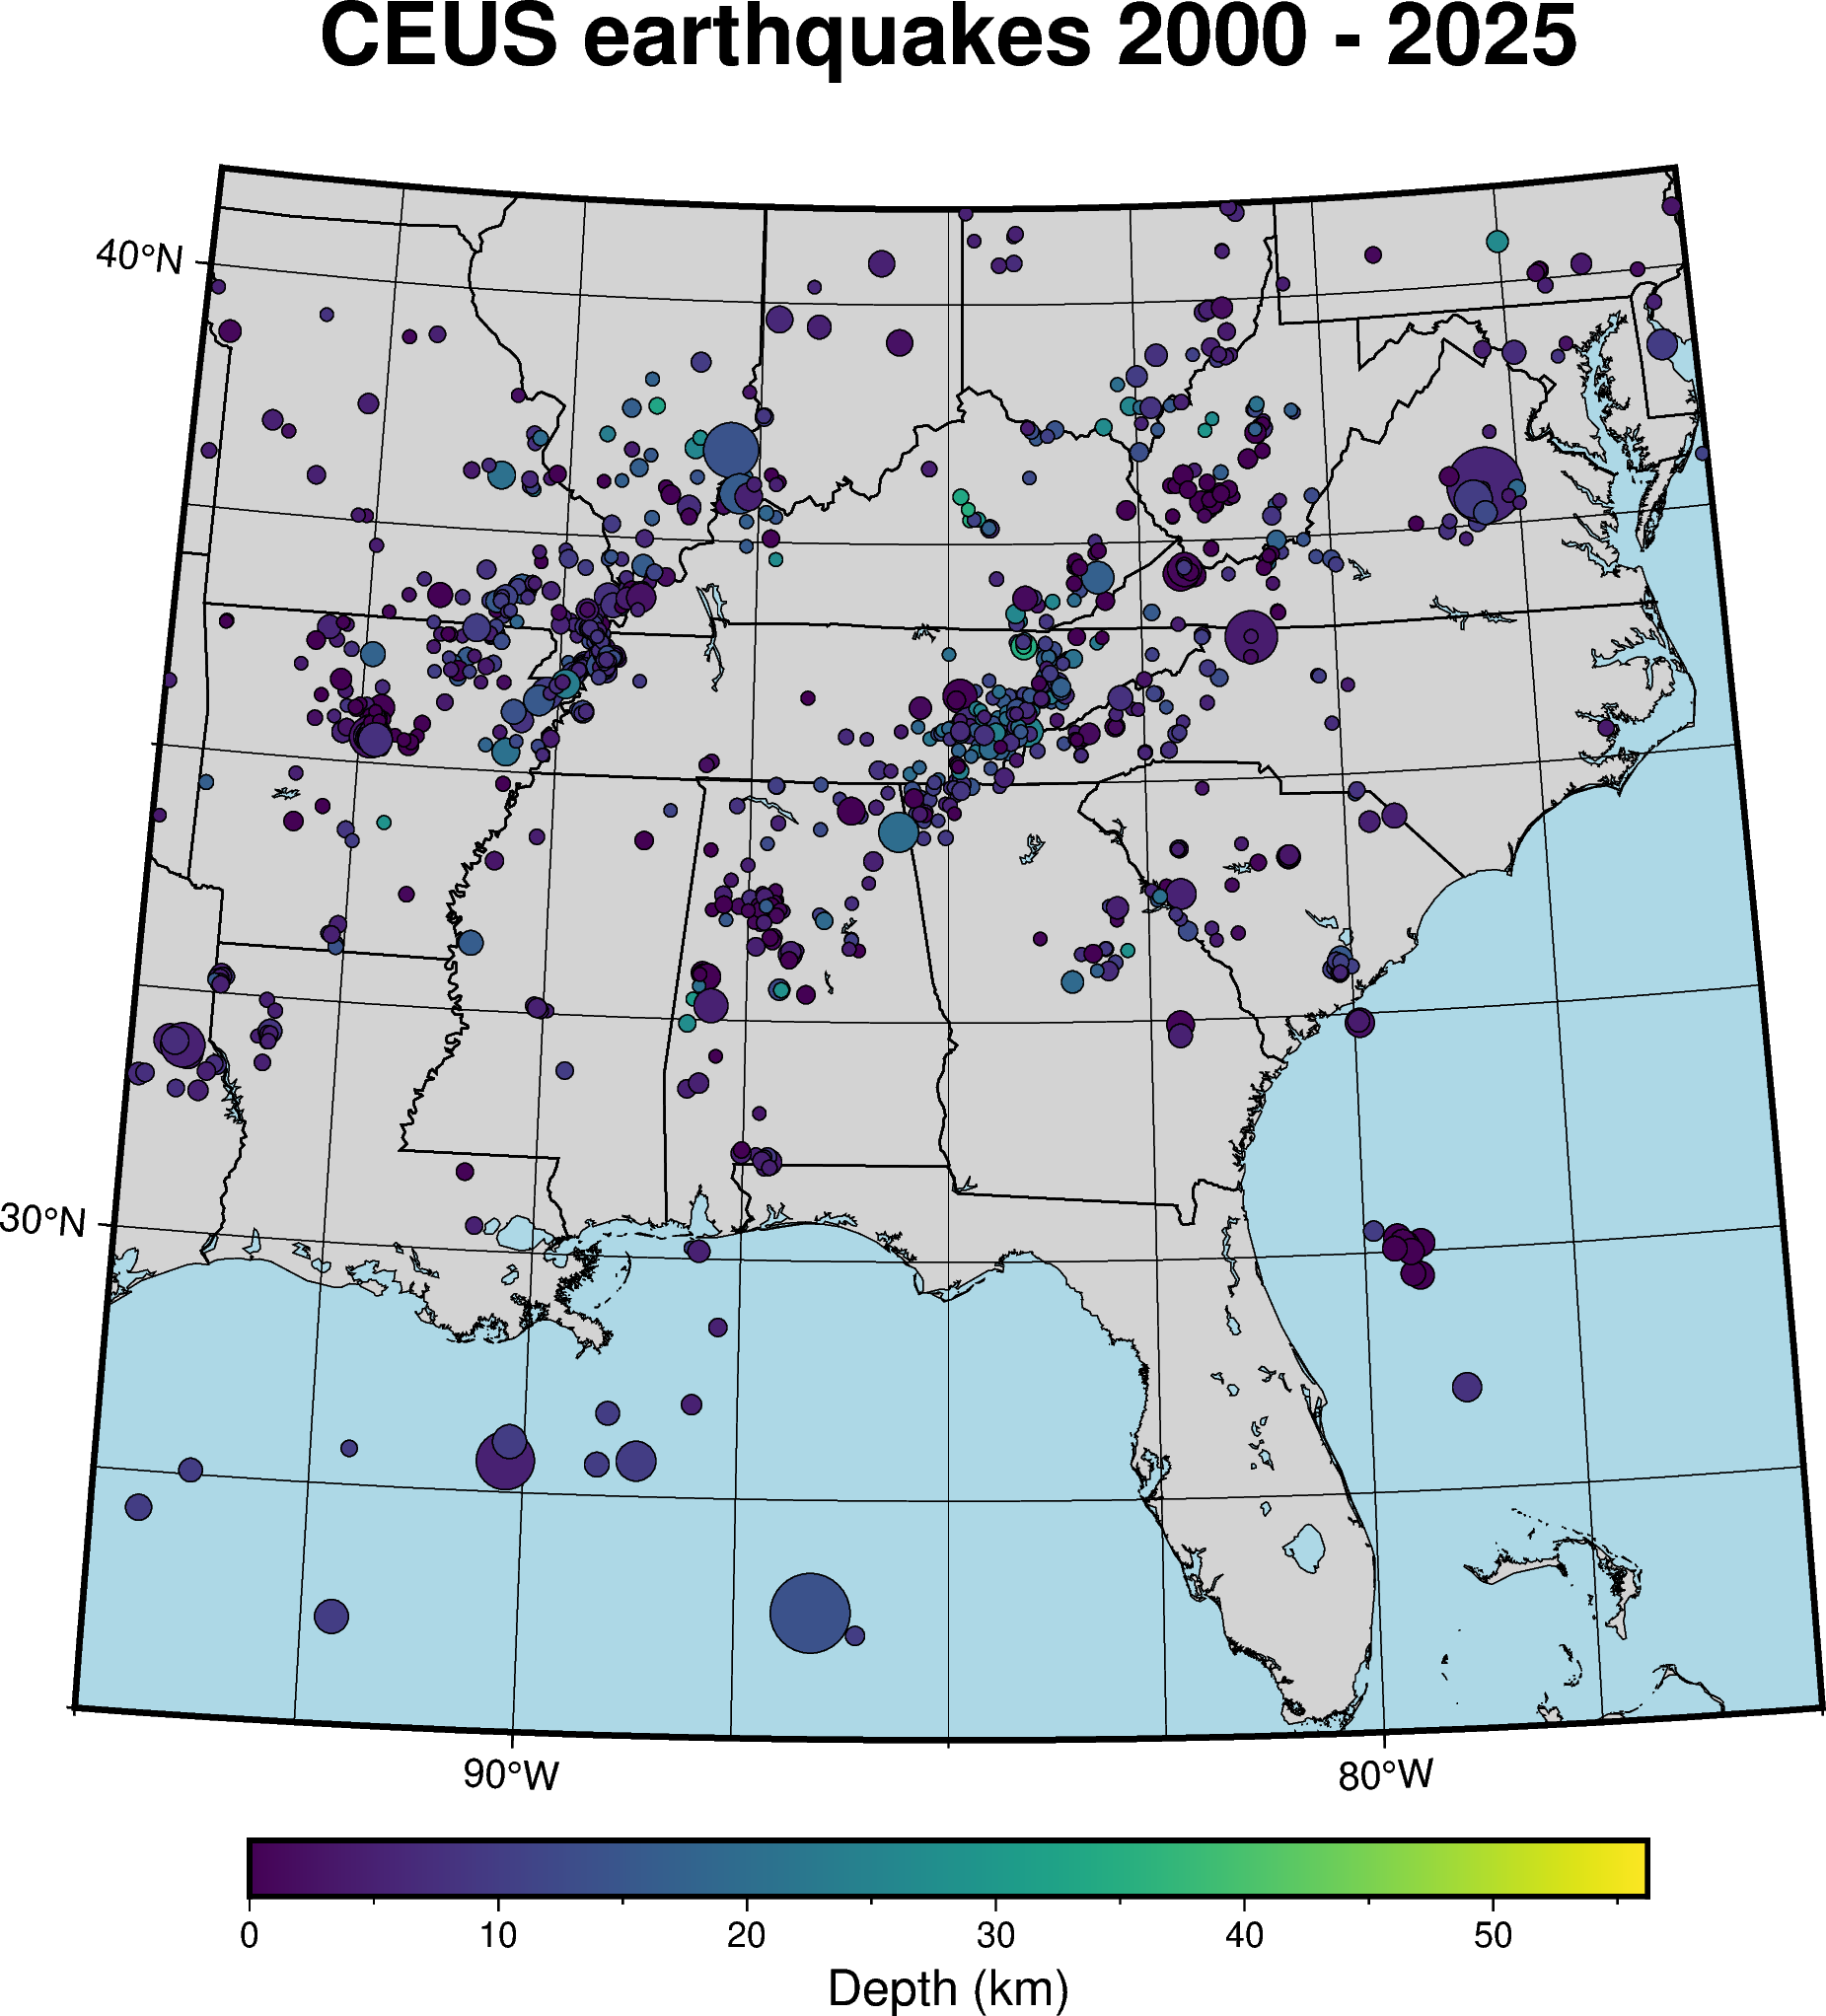

In [33]:
fig3 = pygmt.Figure()
fig3.coast(region=region, projection="T-85/33/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
fig3.basemap(frame=["a10f5g2.5",'+tCEUS earthquakes 2000 - 2025'])

pygmt.makecpt(
    cmap="matplotlib/viridis", series=[data.depth.min(), data.depth.max()], 
    background=True
)

fig3.plot(
    x=data.longitude,
    y=data.latitude,
    size=0.03 * 1.7**data.mag, ## Power law: The factor 0.03 is a factor scale to keep circles within the map 
    fill=data.depth,
    cmap=True,
    style="c",
    pen="black",
)

fig3.colorbar(frame="a10f5+lDepth (km)") # Annotations and ticks each 10, and 5 km, respectively, with text annotation "Depth (km)"

fig3.show()

The colormap range seems inadequate (almost all circles are filled with blue). This happens because our dataset is highly skewed, with some events having a significantly deeper epicenter than the average:

In [34]:
data.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,11357.000000,11357.000000,11357.000000,11357.000000,3097.000000,10657.000000,3447.000000,10777.000000,8783.000000,10554.000000,3774.000000,3979.000000
mean,36.110617,-95.792974,5.909451,2.854116,34.477236,74.893446,0.245038,0.459413,1.595943,4.512640,0.144827,31.104549
std,1.790872,4.707200,2.908853,0.366038,33.740644,38.842173,0.414024,0.256009,2.092555,3.601498,0.119848,30.484245
min,25.650000,-98.523500,0.000000,2.460000,3.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.718500,-97.777000,4.915000,2.600000,13.000000,50.000000,0.028965,0.250000,1.000000,1.982250,0.066000,10.000000
50%,36.263700,-97.407900,5.314000,2.710000,21.000000,67.000000,0.100000,0.440000,1.400000,4.800000,0.108000,21.000000
75%,36.754700,-96.903500,6.711000,3.000000,45.000000,91.000000,0.279700,0.610000,1.823907,7.000000,0.200000,41.000000
max,44.380000,-64.538600,56.210000,5.900000,590.000000,347.000000,6.219000,2.880000,99.000000,99.000000,1.642000,280.000000


We can limit our colorbar to only the 1st and 99th percentiles. To color values outside the limits, we have to pass the attribute  `background = True` to `pygmt.makecpt()`. We can draw triangles for the background colors in our colorbar by passing the attributes `bg_triangle = True` and `fg_triangle = True` to `fig.colorbar()`:

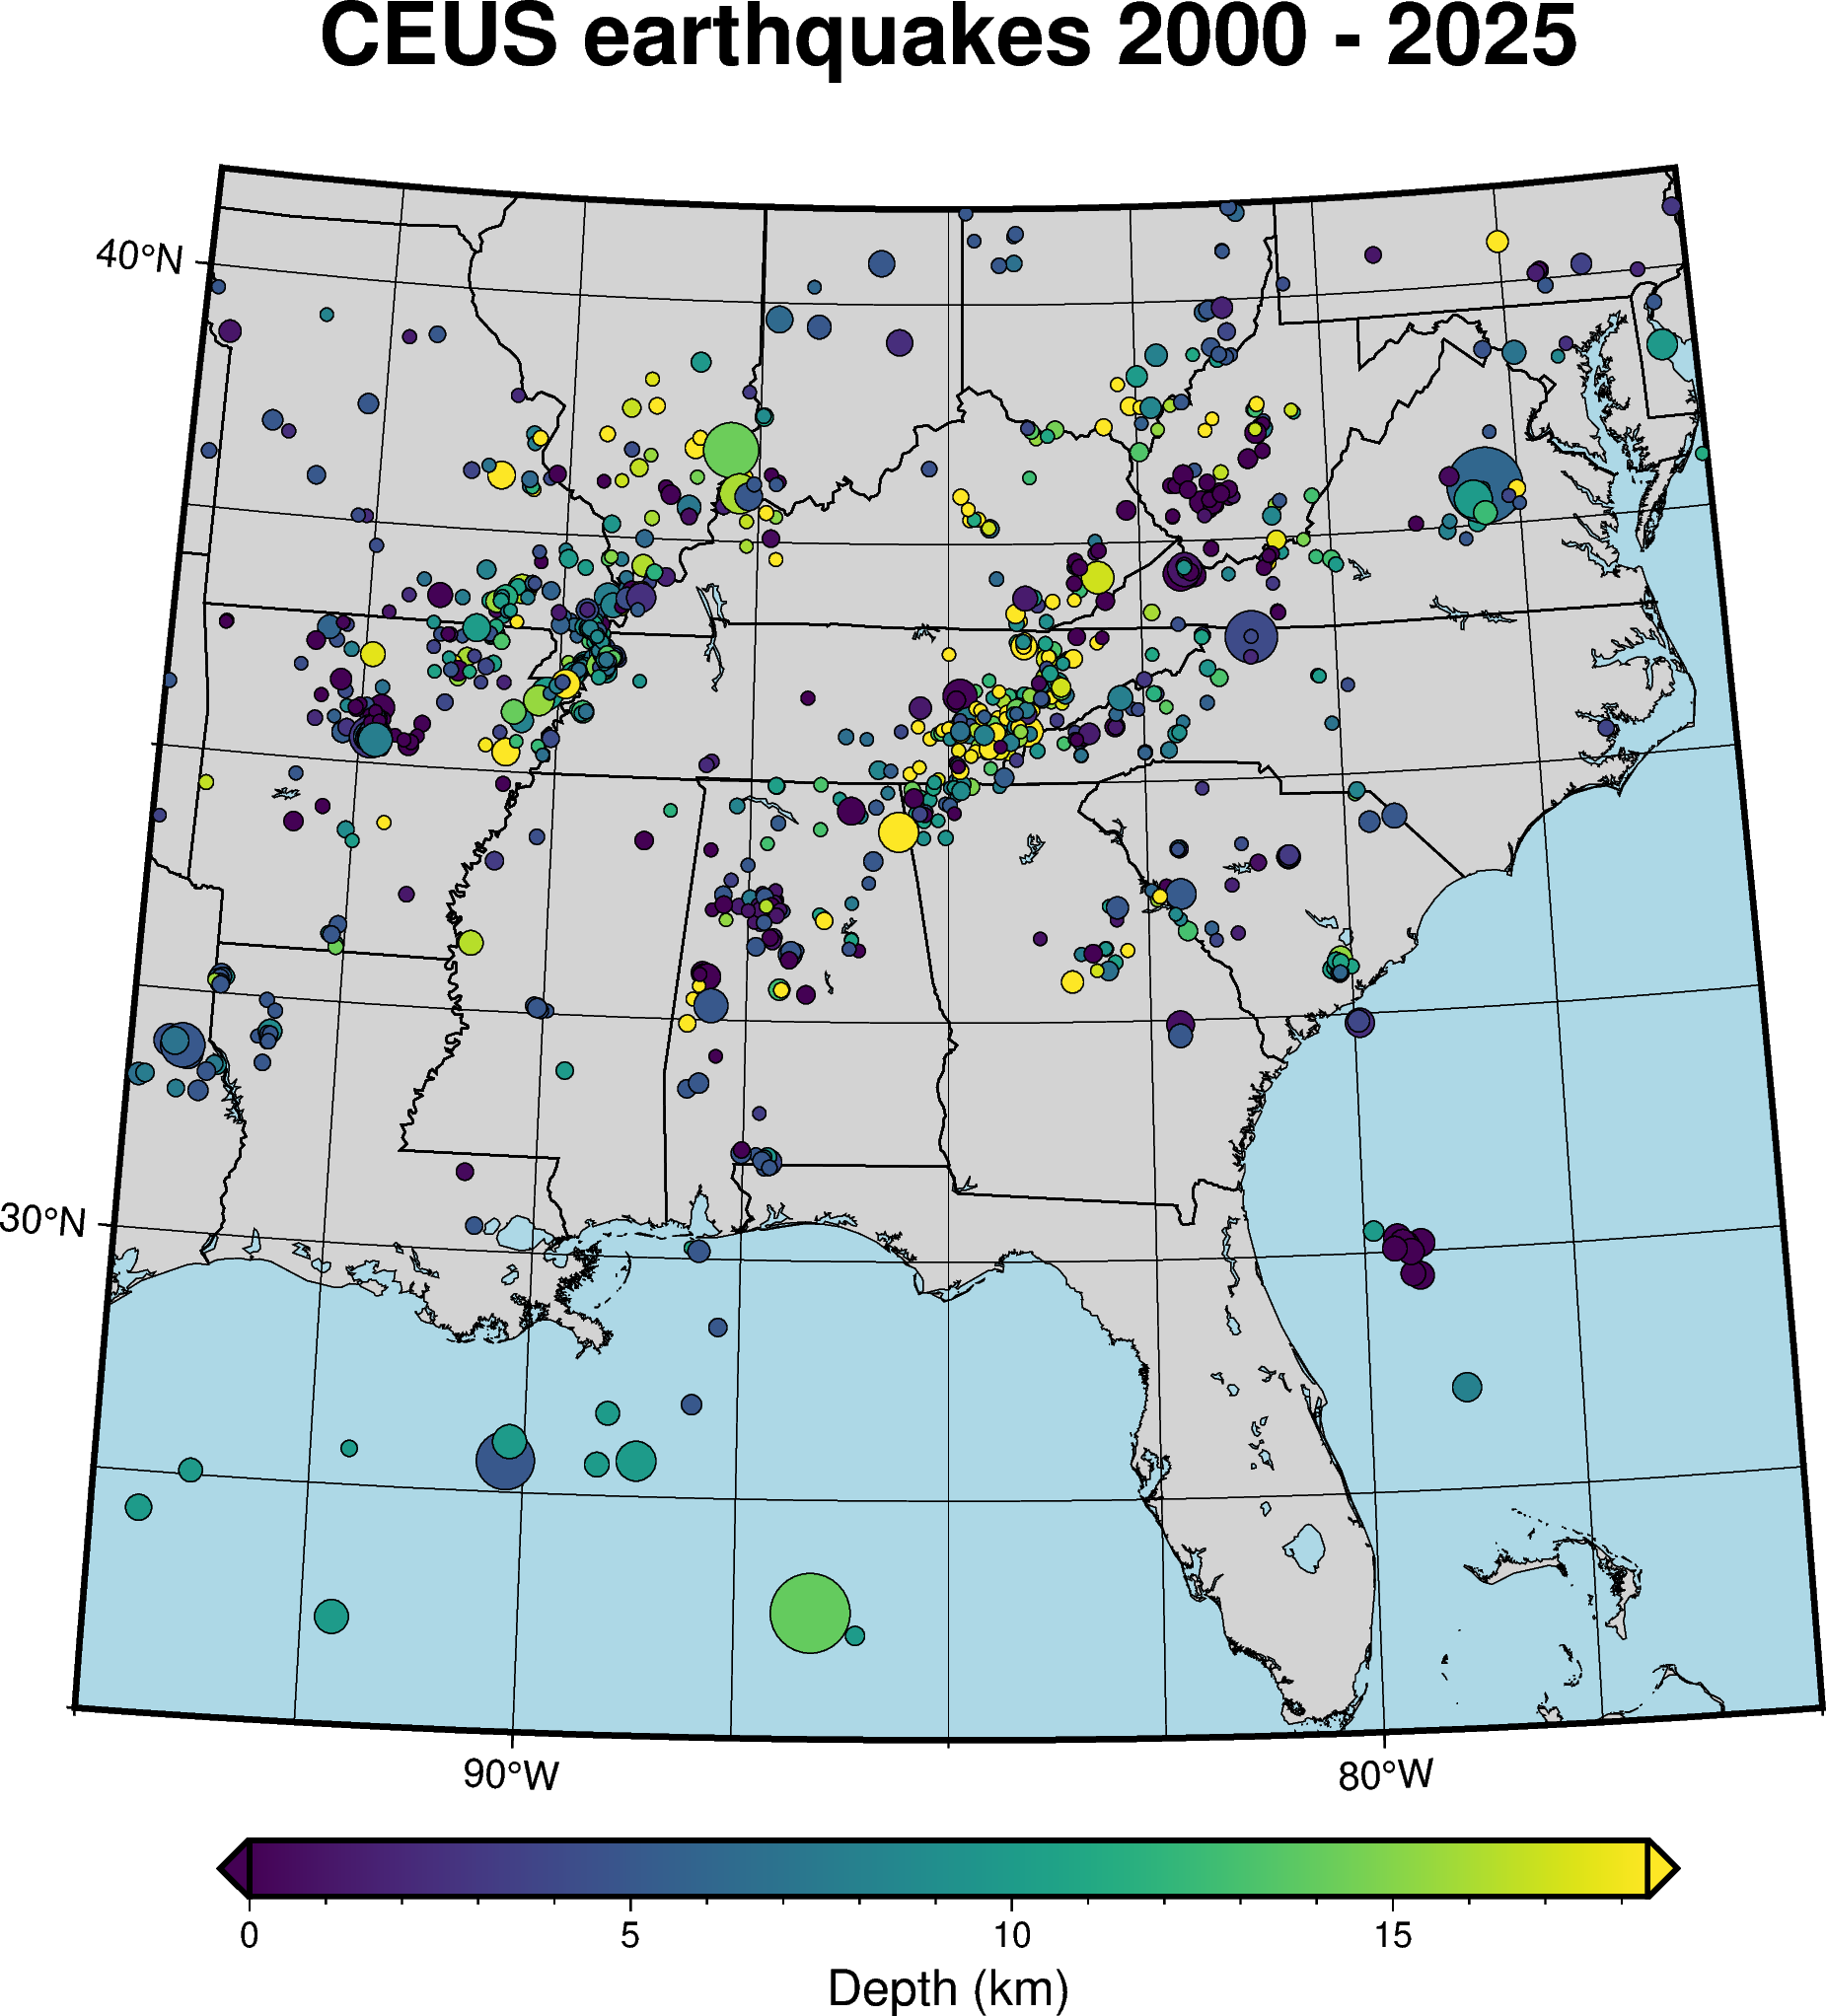

In [35]:
fig3 = pygmt.Figure()
fig3.coast(region=region, projection="T-85/33/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
fig3.basemap(frame=["a10f5g2.5",'+tCEUS earthquakes 2000 - 2025'])

vmin = data.depth.quantile(0.01)
vmax = data.depth.quantile(0.99)

pygmt.makecpt(
    cmap="matplotlib/viridis", series=[vmin, vmax], 
    background=True
)

fig3.plot(x=data.longitude, y=data.latitude, size=0.03 * 1.7**data.mag, fill=data.depth, cmap=True, style="c", pen="black")

fig3.colorbar(
    frame="a5f1+lDepth (km)", 
    bg_triangle=True,   ## Background triangle
    fg_triangle=True    ## Foreground triangle
)

fig3.show()

Finally, we can define a legend for the size of the circles using the `fig.legend()` method:

- `spec`: [legend specification](https://docs.generic-mapping-tools.org/6.6/legend.html)
- `position`: Position of the legend on the plot, with the following characteristics:
    - Position: [Reference point](https://www.pygmt.org/dev/techref/justification_codes.html) based on a two-character code, *i.e.*, **TL** for top left, **MR** for middle right, or **BC** for bottom center. We can specify an offset to adjust the position.
    - `line_spacing`: Line-spacing factor between legend entries in units of font size
    - `box`: Draw a background box behind the legend

Given the complexity of the legend, it has to be defined manually using `io.StringIO()` objects. For more details about legends, check https://www.pygmt.org/latest/tutorials/advanced/legends.html.

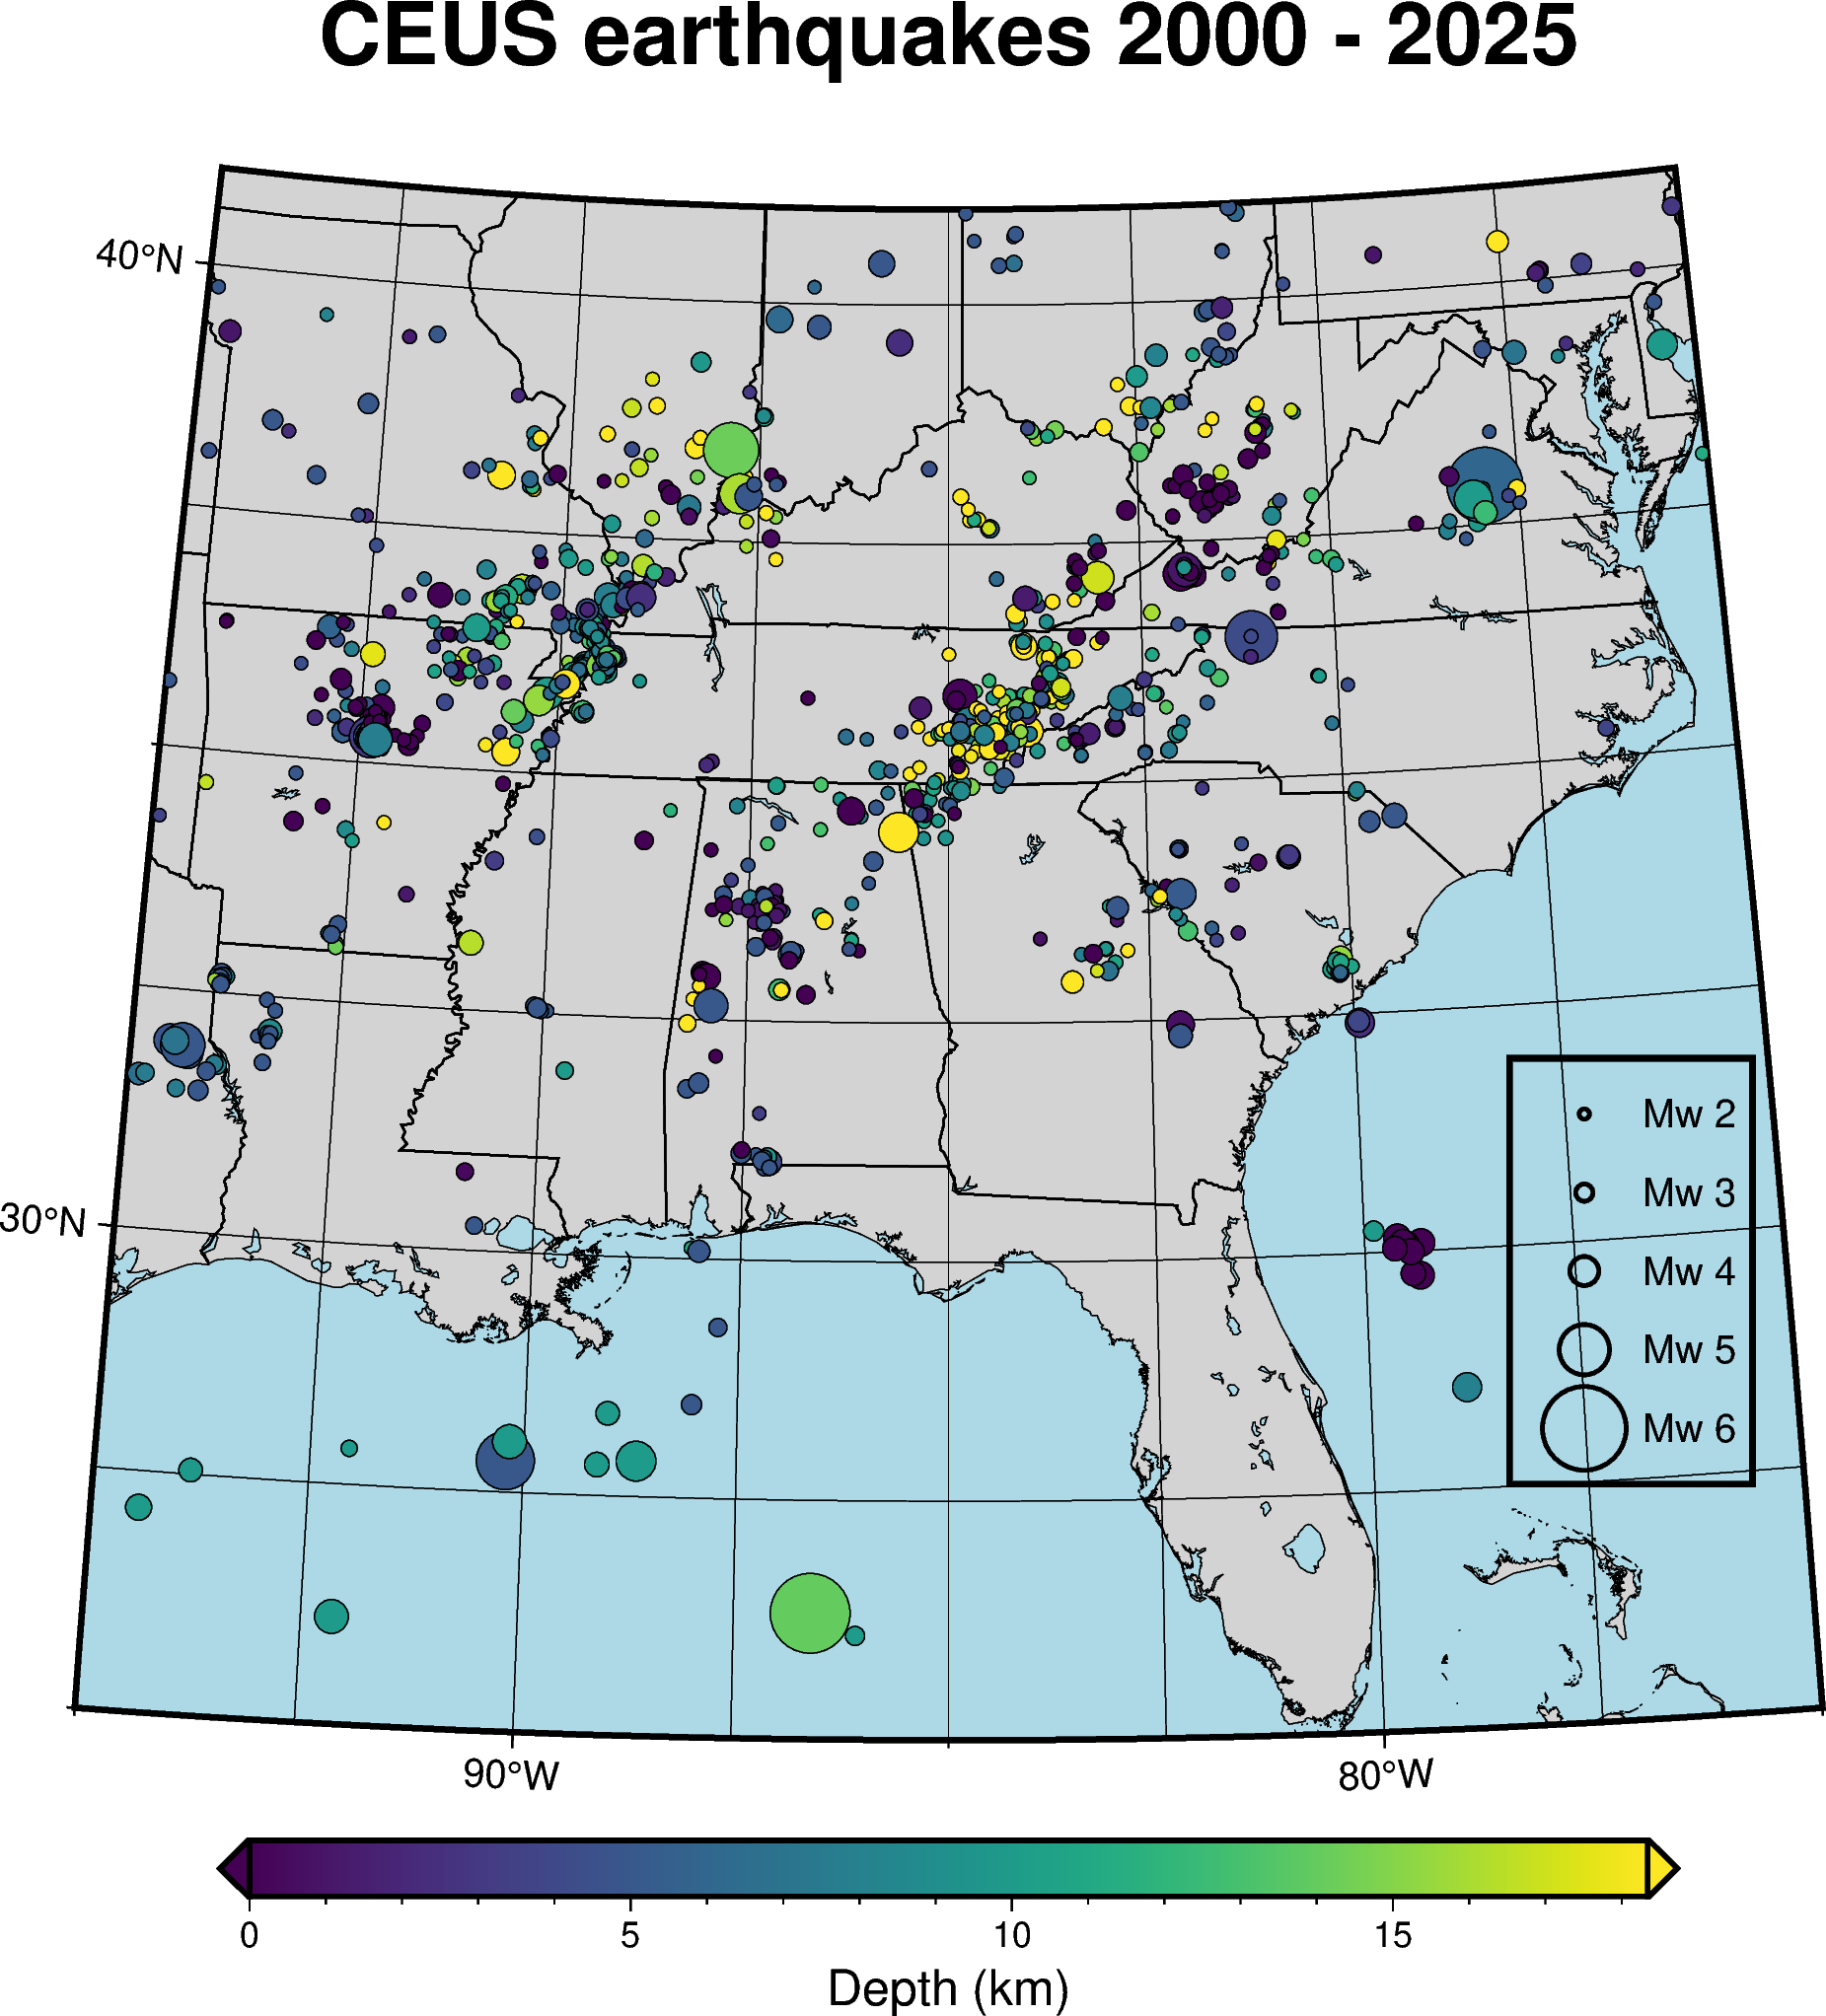

In [36]:
import io
from pygmt.params import Position

fig3 = pygmt.Figure()
fig3.coast(region=region, projection="T-85/33/15c", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
fig3.basemap(frame=["a10f5g2.5",'+tCEUS earthquakes 2000 - 2025'])

vmin = data.depth.quantile(0.01)
vmax = data.depth.quantile(0.99)

pygmt.makecpt(
    cmap="matplotlib/viridis", series=[vmin, vmax], 
    background=True
)

fig3.plot(x=data.longitude, y=data.latitude, size=0.03 * 1.7**data.mag, fill=data.depth, cmap=True, style="c", pen="black")

fig3.colorbar(
    frame="a5f1+lDepth (km)", 
    bg_triangle=True,   ## Background triangle
    fg_triangle=True    ## Foreground triangle
)

magnitudes = [2, 3, 4, 5, 6]
legend = io.StringIO(
    #A symbol (S) type circle (c) with an horizontal offset of 0.5 cm, size 0.03*1.7^m without fill (-) and 1 point borderline.
    #Follow by a text of width 1 cm 
    "\n".join(f"S 0.5 c {0.03 * 1.7**m:.2f} - 1p 1 Mw {m}" for m in [2, 3, 4, 5, 6])  
)
fig3.legend(spec=legend, position=Position("BR", offset=[0.6,2.2]), line_spacing=2.0, box=True)
fig3.savefig('fig/CEUS_eqks_2000_2025.png',  transparent=True, dpi=300)
fig3.show()

## 2.3. Gridded data and inset maps: Earth relief and Advanced National Seismic System (ANSS) stations in CEUS

We will plot the location of the Advanced National Seismic System [(ANSS)](https://www.usgs.gov/programs/earthquake-hazards/anss-advanced-national-seismic-system). ANSS is composed of national and regional seismic networks and associated data centers, including the [National Earthquake Information Center (NEIC)](https://www.usgs.gov/programs/earthquake-hazards/national-earthquake-information-center-neic) and the [National Strong Motion Project](https://earthquake.usgs.gov/monitoring/nsmp/). The locations of the seismic stations are on the [USGS webpage](https://earthquake.usgs.gov/monitoring/operations/network.php?virtual_network=ANSS). This information is saved in **data/anss_stations_2026.csv**:

In [37]:
stations = pd.read_csv("data/anss_stations_2026.csv")
stations.head()

,Network,Station,name,latitude,longitude,elevation
0,IW,DLMT,"Dillon, Montana, USA",45.362500,-112.596400,1569
1,IW,FLWY,"Flagg Ranch, Wyoming, USA",44.083002,-110.699888,2078
2,IW,FXWY,"Fox Creek, Wyoming, USA",43.638100,-111.026800,2254
3,IW,IMW,"Indian Meadow, Wyoming, USA",43.893030,-110.943430,2552
4,IW,LOHW,"Long Hollow, Wyoming USA",43.612400,-110.603800,2121


In this example, we will focus in CEUS stations:

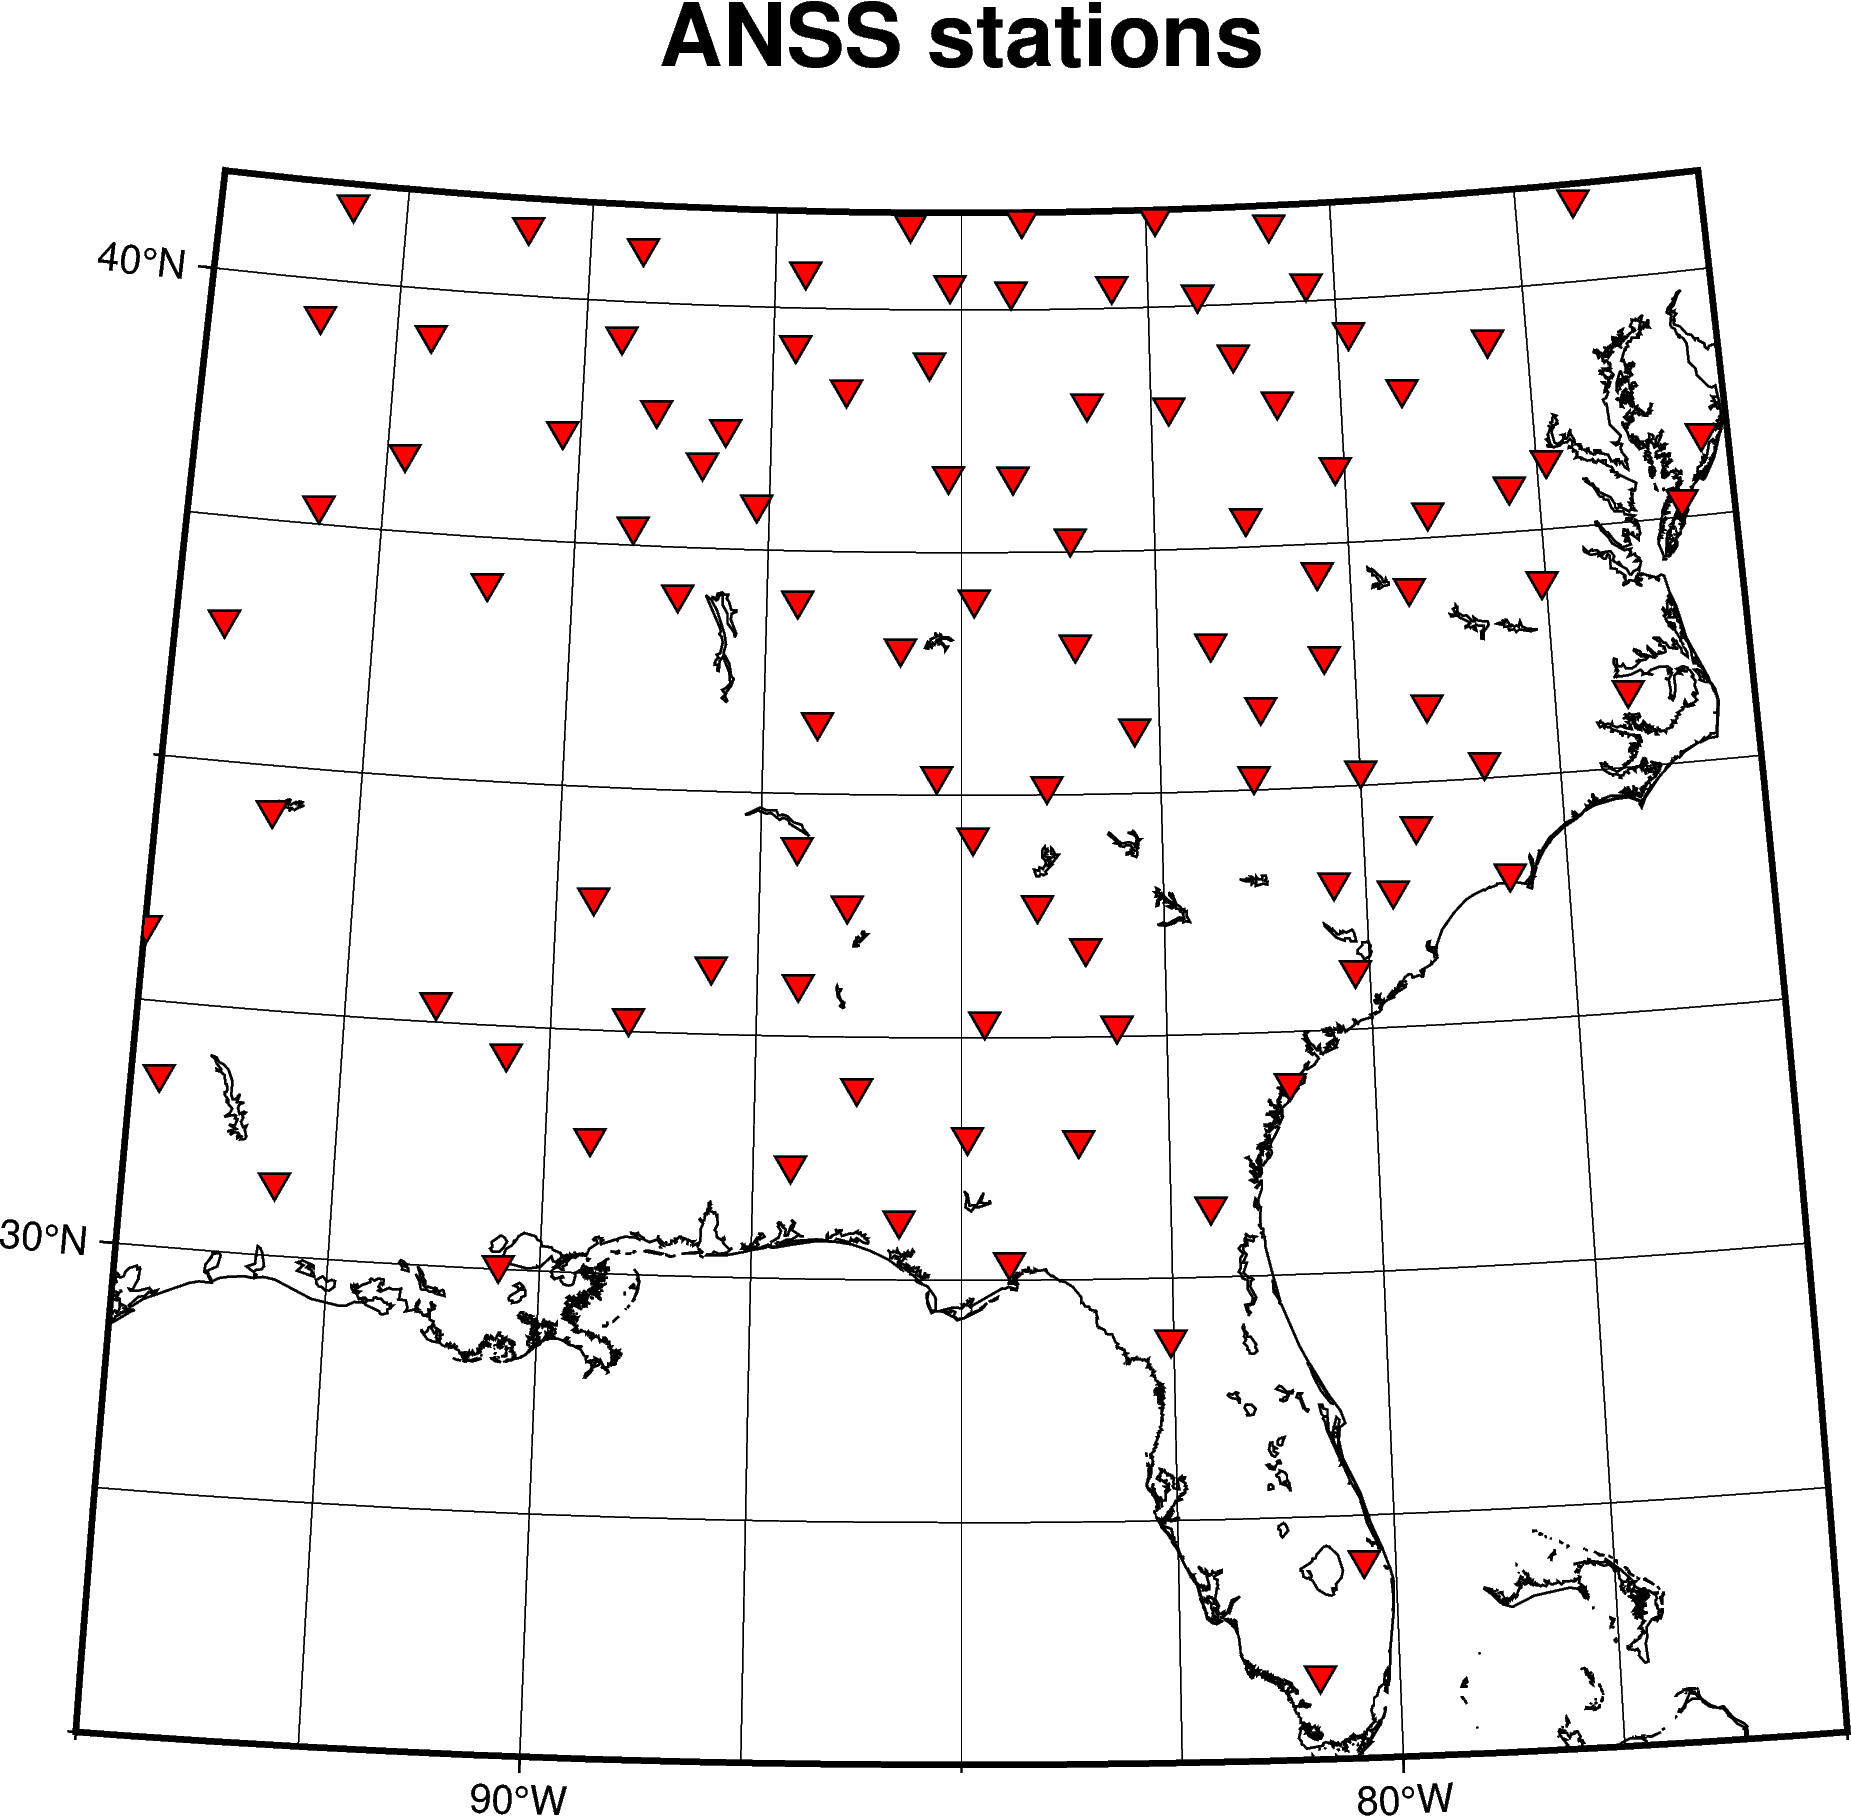

In [38]:
fig4 = pygmt.Figure()

fig4.coast(region=region, projection="T-85/33/15c", shorelines="0.5p,black")
fig4.basemap(frame=["a10f5g2.5", '+tANSS stations'])

fig4.plot(x=stations.longitude, y=stations.latitude,
    style="i0.3c",  # i for triangles
    fill="red",
    pen="0.5p,black"
)

fig4.show()


We will add information about Earth relief to our map using the function `pygmt.datasets.load_earth relief()`. This function downloads topography and bathymetry at various resolutions from the GMT data server and loads them as `xarray.DataArray`. For this, we have to define:

- `resolution`: Grid resolution. Options include: `'01d', '30m', '20m', '15m', '10m', '06m', '05m', '04m', '03m', '02m', '01m', '30s', '15s', '03s', '01s'`, where the suffix **d, m, s** stand for arc-degrees, arc-minutes, and arc-seconds (default = '01d'). 
- `region`: Subregions of the grid to load.
- `registration`: Grid registration type, either `pixel` (data points fall exactly in the center of the grid) or `gridline` (data points fall exactly on the intersection of the grid) (default = 'gridline').

For more information about the available datasets, refer to https://www.generic-mapping-tools.org/remote-datasets/earth-relief.html. In our example, we will use a resolution of `02m` (2 arc-minutes):

In [39]:
grid = pygmt.datasets.load_earth_relief(resolution="02m", region=region)
grid.head()

<xarray.DataArray 'z' (lat: 5, lon: 5)> Size: 100B
array([[-3580.5, -3594.5, -3600.5, -3604. , -3603.5],
       [-3564.5, -3580.5, -3589. , -3592. , -3592. ],
       [-3550. , -3563.5, -3572. , -3577. , -3579.5],
       [-3537.5, -3549.5, -3558. , -3563.5, -3567.5],
       [-3526.5, -3537.5, -3546. , -3552. , -3556.5]], dtype=float32)
Coordinates:
  * lat      (lat) float64 40B 25.0 25.03 25.07 25.1 25.13
  * lon      (lon) float64 40B -95.0 -94.97 -94.93 -94.9 -94.87
Attributes:
    Conventions:       CF-1.7
    title:             
    history:           gmt grdblend @earth_relief_02m_g/ -R-95/-75/25/41 -I02...
    description:       IGPP Earth relief
    long_name:         z
    units:             meters
    vertical_datum:    EGM96
    horizontal_datum:  WGS84

Another way to check our grid information is using `pygmt.grdinfo()`:

In [40]:
print(pygmt.grdinfo(grid=grid))

: Title: 
: Command: 
: Remark: 
: Gridline node registration used [Geographic grid]
: Grid file format: nf = GMT netCDF format (32-bit float), CF-1.7
: x_min: -95 x_max: -75 x_inc: 0.0333333333333 (2 min) name: x n_columns: 601
: y_min: 25 y_max: 41 y_inc: 0.0333333333333 (2 min) name: y n_rows: 481
: v_min: -5101.5 v_max: 1645.5 name: z
: scale_factor: 1 add_offset: 0
: format: classic
: Default CPT: 



The grid information was downloaded in **netCDF** format. [**Network Common Data Form (netCDF)**](https://docs.unidata.ucar.edu/nug/current/?rsource=https%3A%2F%2Flinks.esri.com%2Fnetcdf_UserGuide) is a machine-independent binary file format (not tied to a specific computer hardware architecture and can run on any operating system) used to store multi-dimensional scientific data. It is commonly used in meteorology, oceanography, and geosciences. `xarray` library is the standard library for working with **netCDF** files in Python. For an introduction to **netCDF** data format and `xarray` package, refer to [Project Pythia](https://foundations.projectpythia.org/core/data-formats/netcdf-cf/).

To visualize the grid data, we can use the `fig.grdimage()` method. Before plotting, we need to define:

- `grid`: Set the grid file loaded as an `xarray.DataArray` object.
- `region`.
- `projection`.
- `cmap`: Set the color palette table.

For this application we will use an specific `cmap` names **geo** ranging from -8000 to 7000 m with increments of 500. To define the range and increment step, we can use the attribute `series`: 



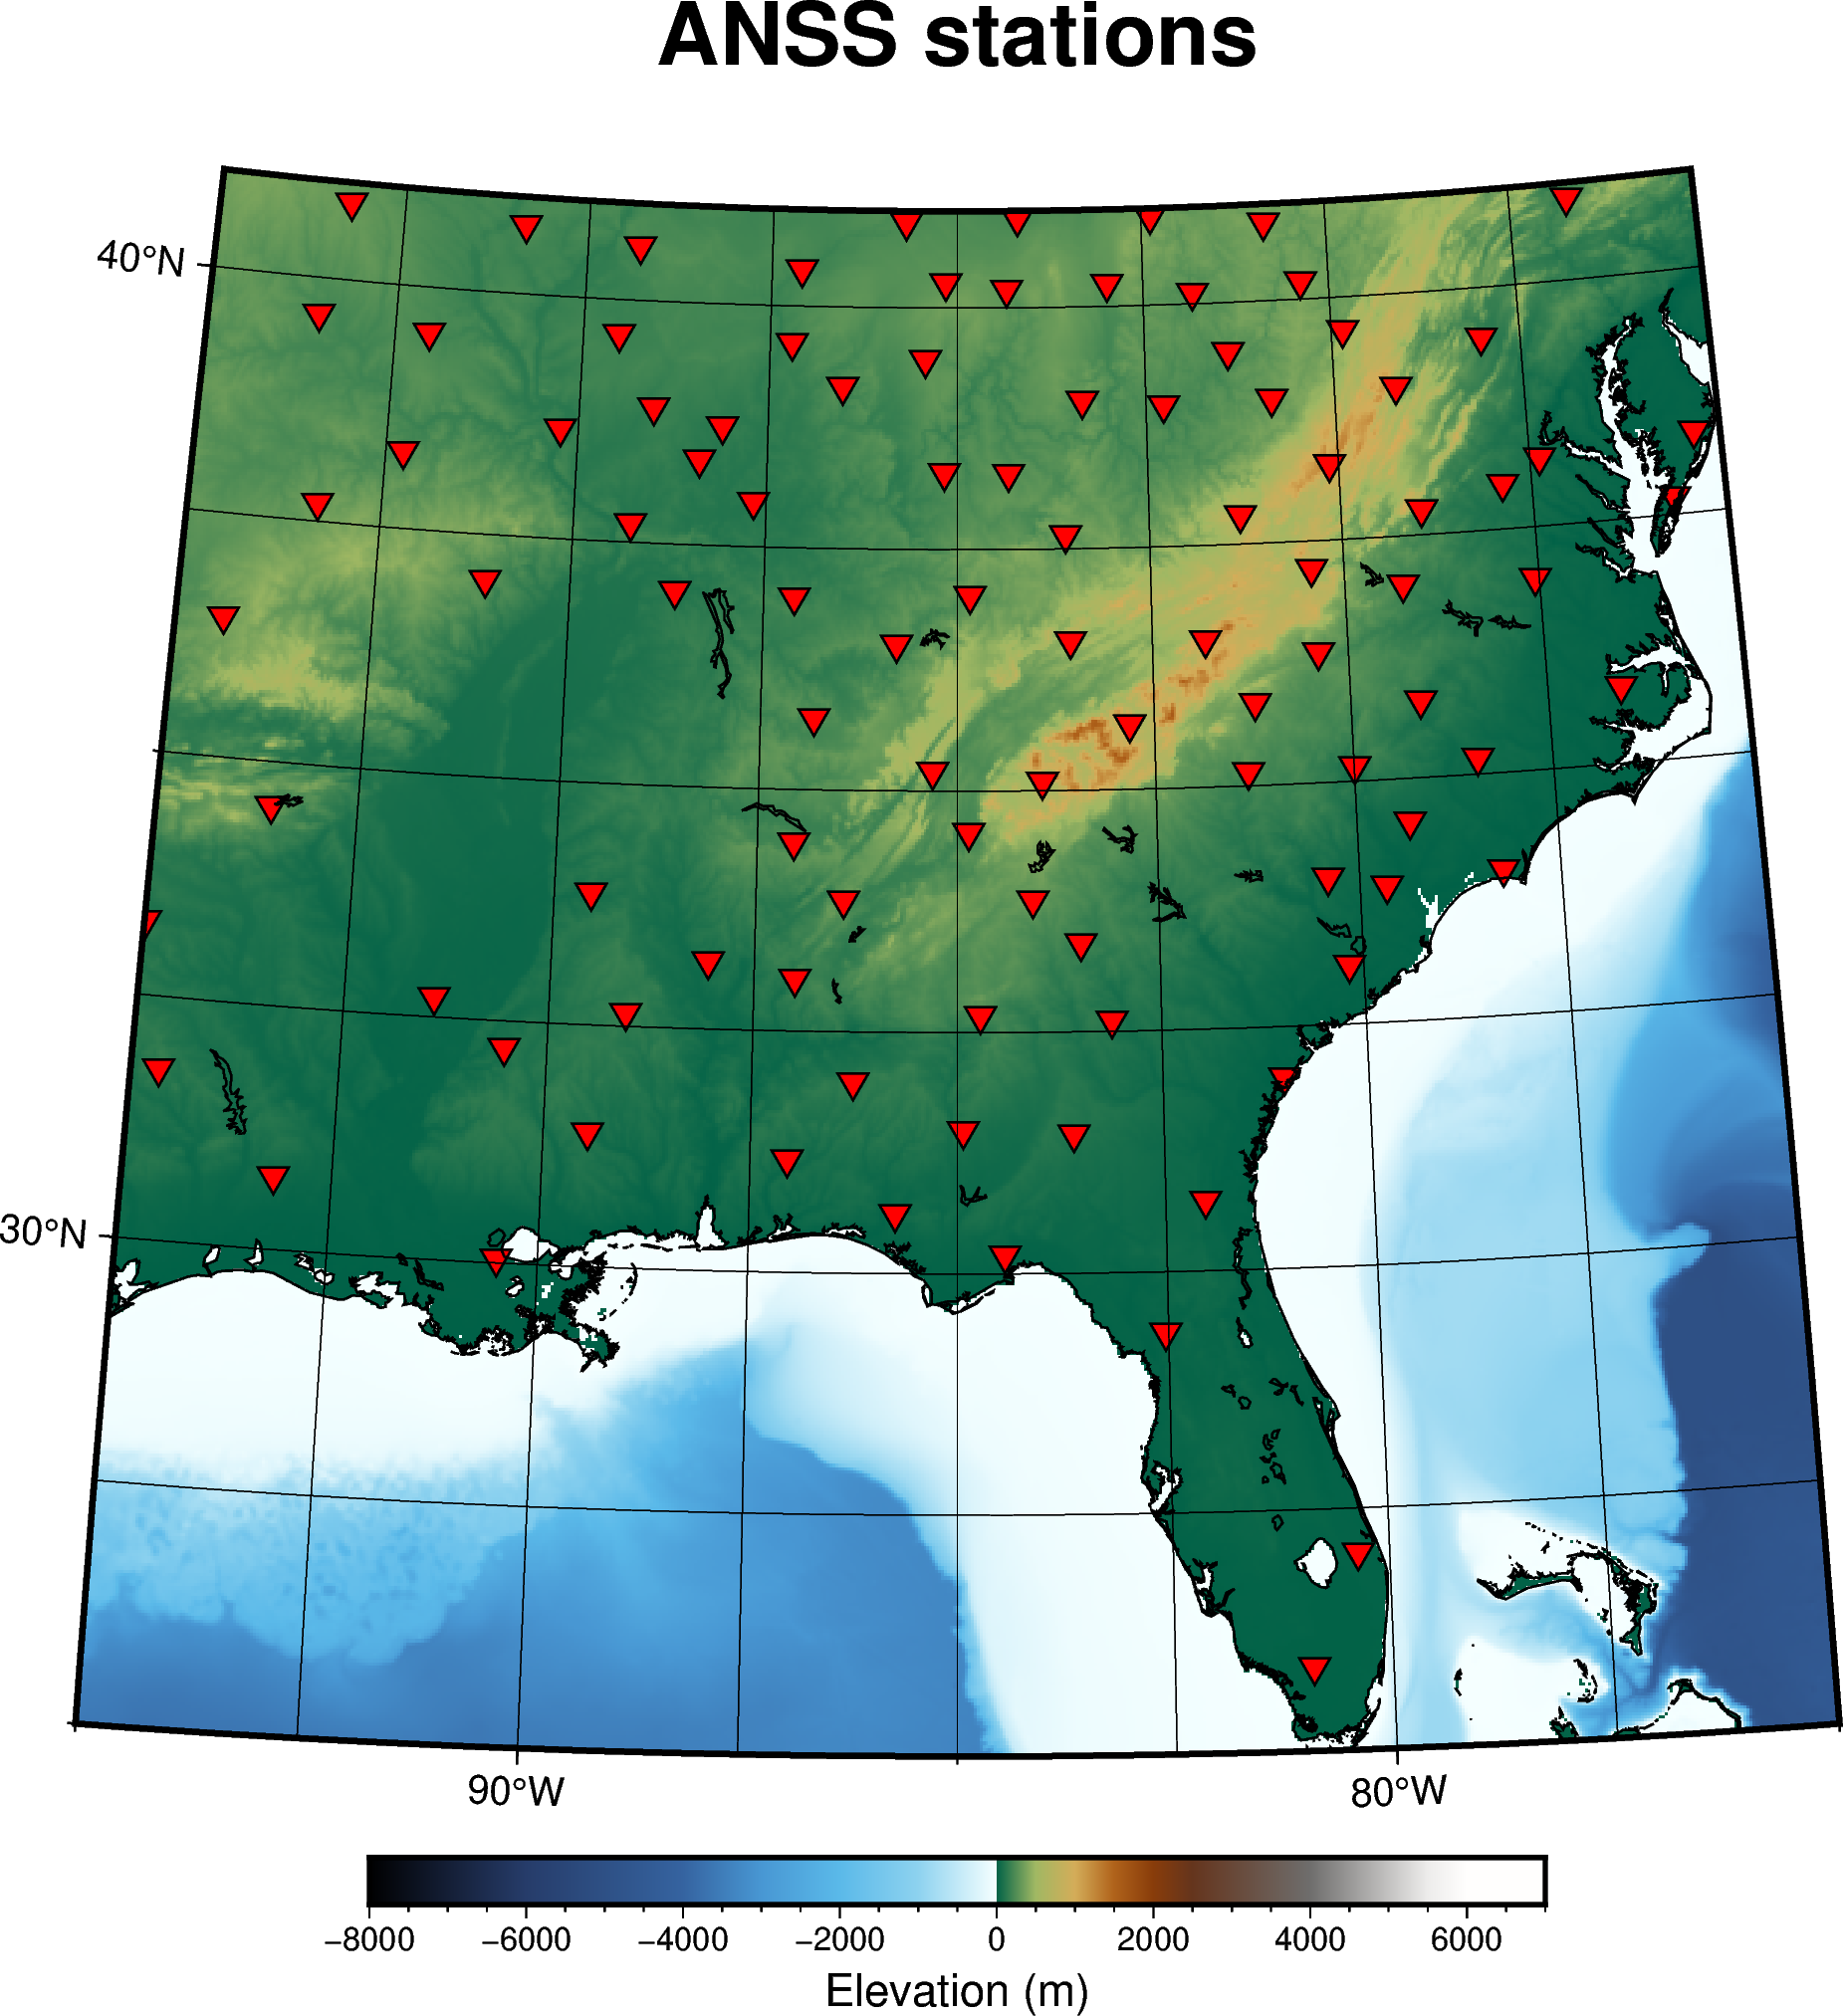

In [41]:
pygmt.makecpt(
    cmap="geo",
    series=[-8000, 7000, 500],
    continuous=True,
    # File name with extension .cpt to store the generated CPT file
    output="data/eleva.cpt",
)

fig4 = pygmt.Figure()

fig4.grdimage(grid=grid, 
              region=region, 
              projection="T-85/33/15c", 
              cmap="data/eleva.cpt")

fig4.plot(x=stations.longitude, y=stations.latitude, style="i0.3c", fill="red", pen="0.5p,black")

fig4.coast(region=region, projection="T-85/33/15c", shorelines="0.5p,black")
fig4.basemap(frame=["a10f5g2.5", '+tANSS stations'])

fig4.colorbar(cmap="data/eleva.cpt", frame="a2000f500+lElevation (m)", position="JBC+w10c/0.4c+mc+h")
fig4.show()


We can add an inset figure inside a larger figure using the `fig.inset()` method with a `with` statement. All plotting methods called within the `with` statement are applied to the inset figure. First, we will learn how to add a box at the bottom left of our figure:

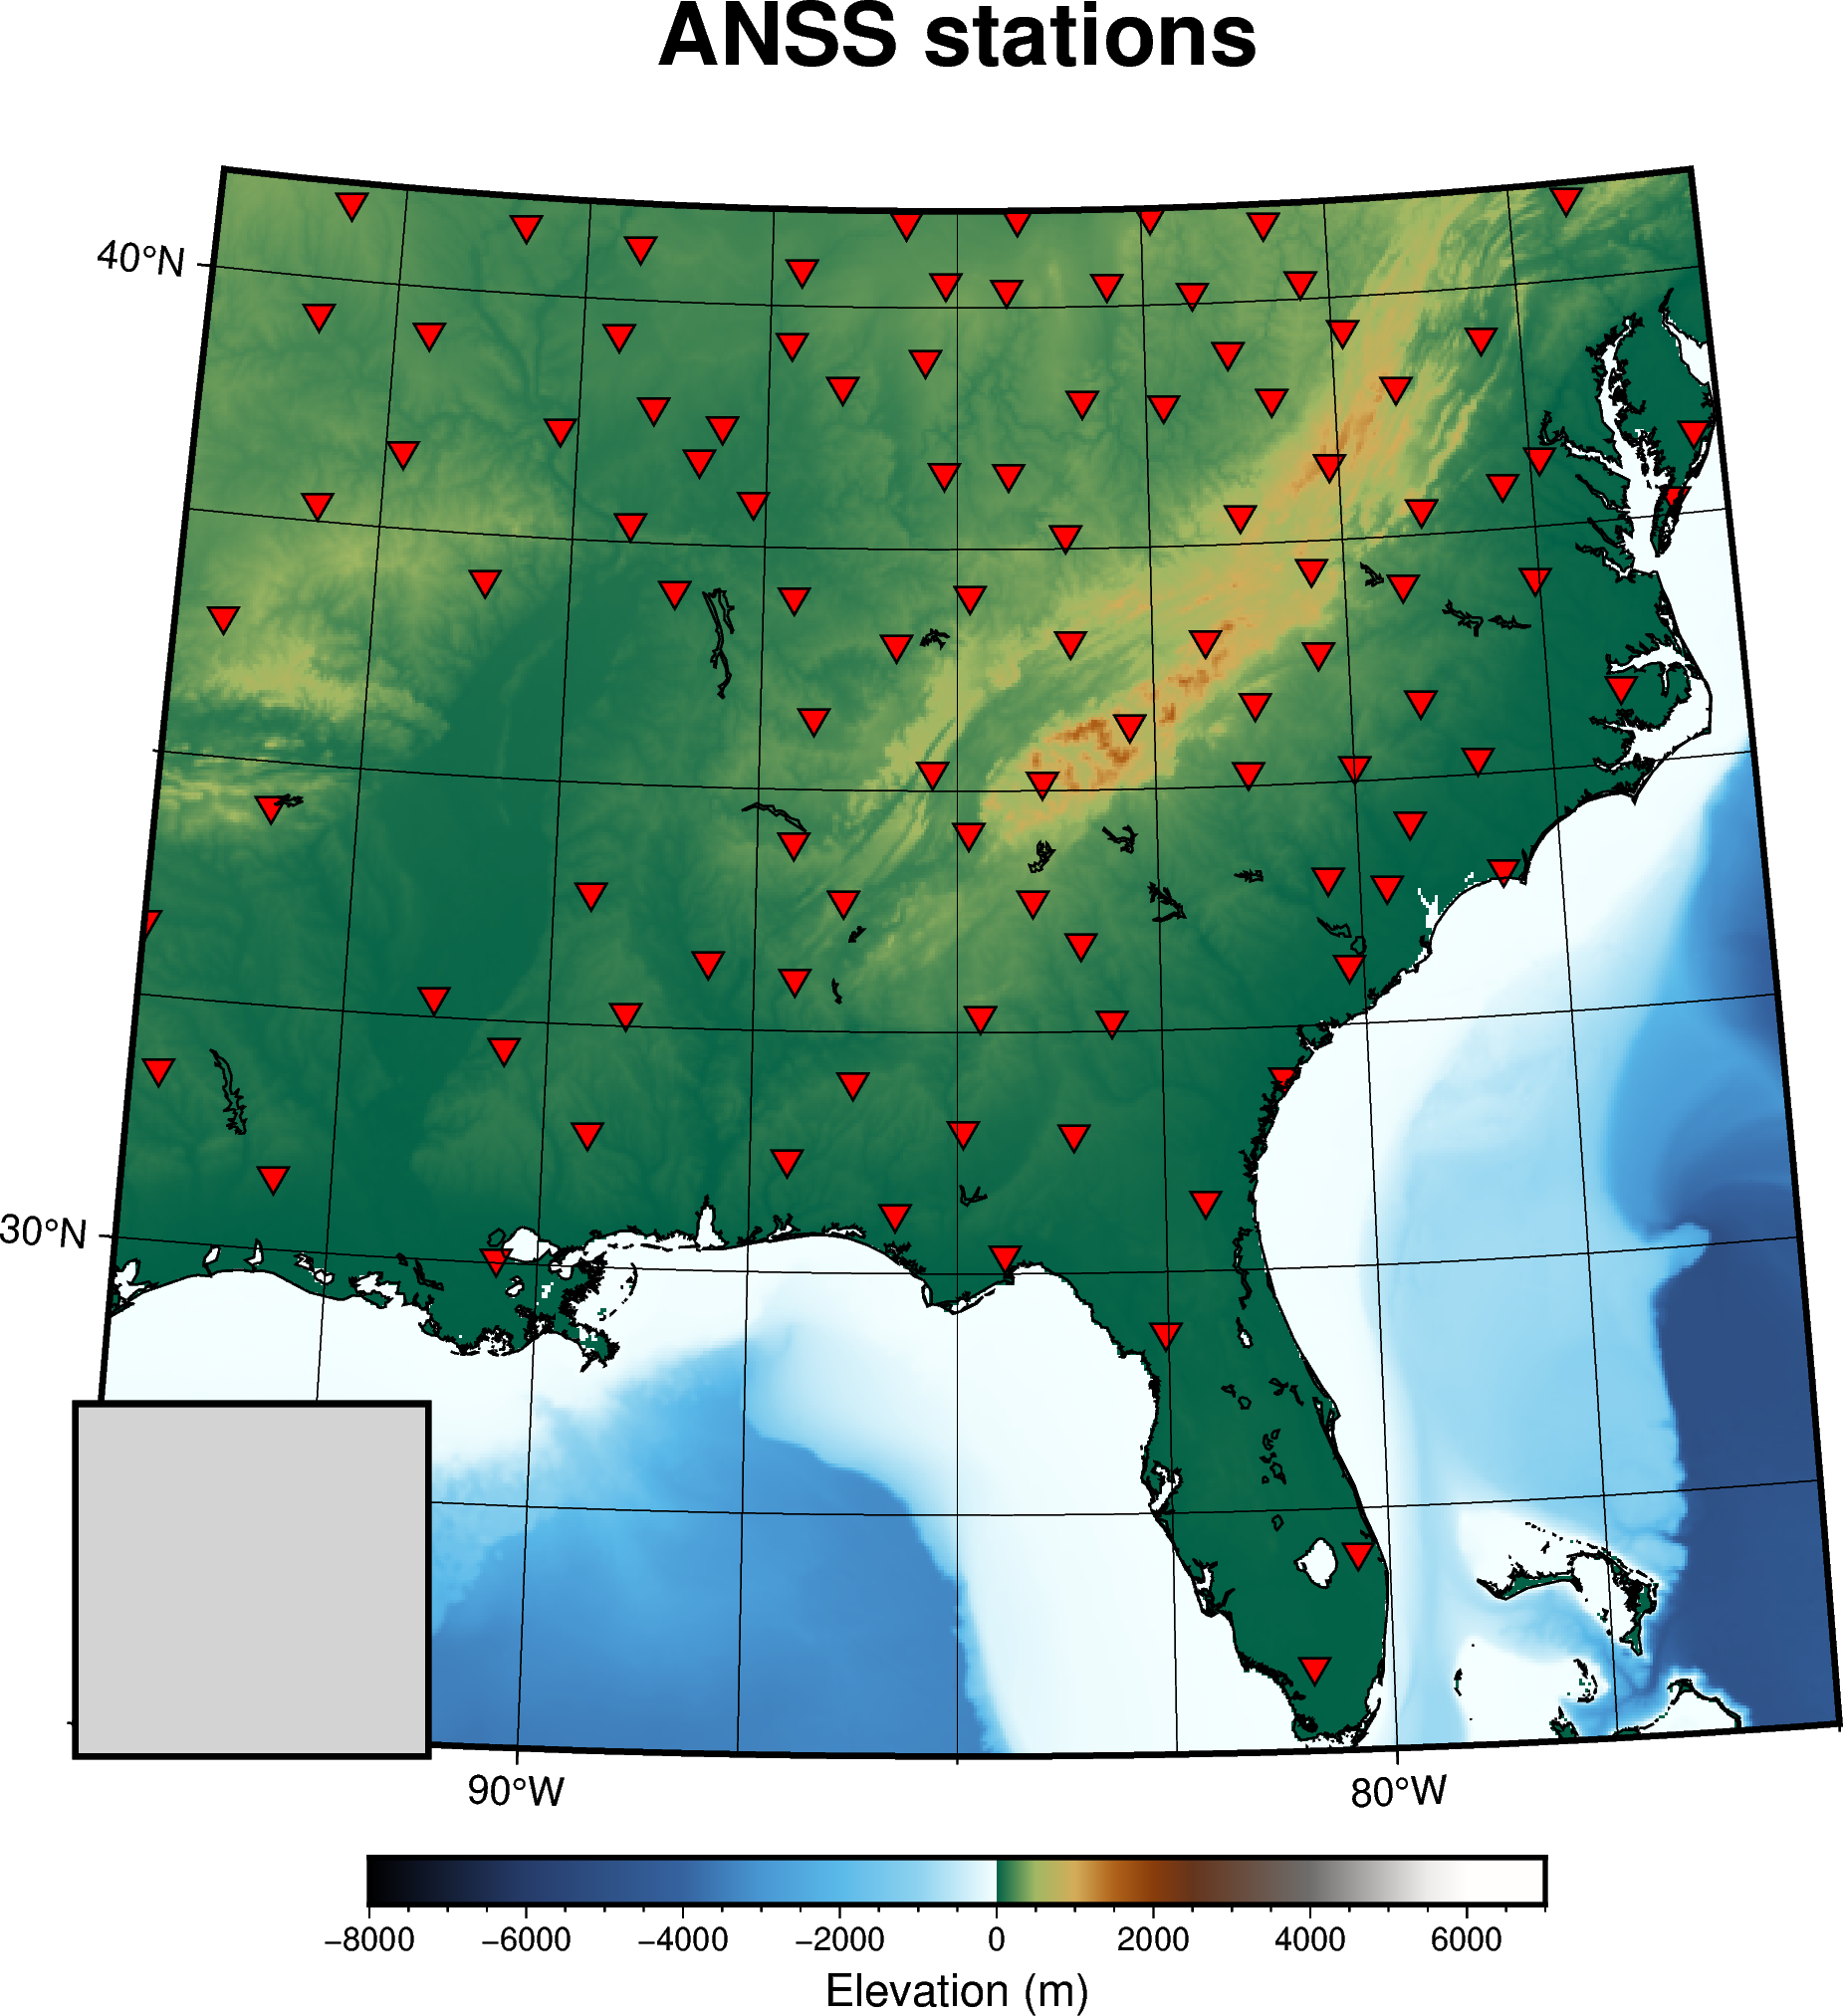

In [42]:
from pygmt.params import Box, Position

with fig4.inset(position=Position("BL"), 
                width=3, 
                box=Box(pen="black", fill="lightgrey")):
    pass # pass is used to exit the with statement as no plotting methods are called

fig4.show()

We can change the location of our inset figure using the `offset` attribute of `position`:

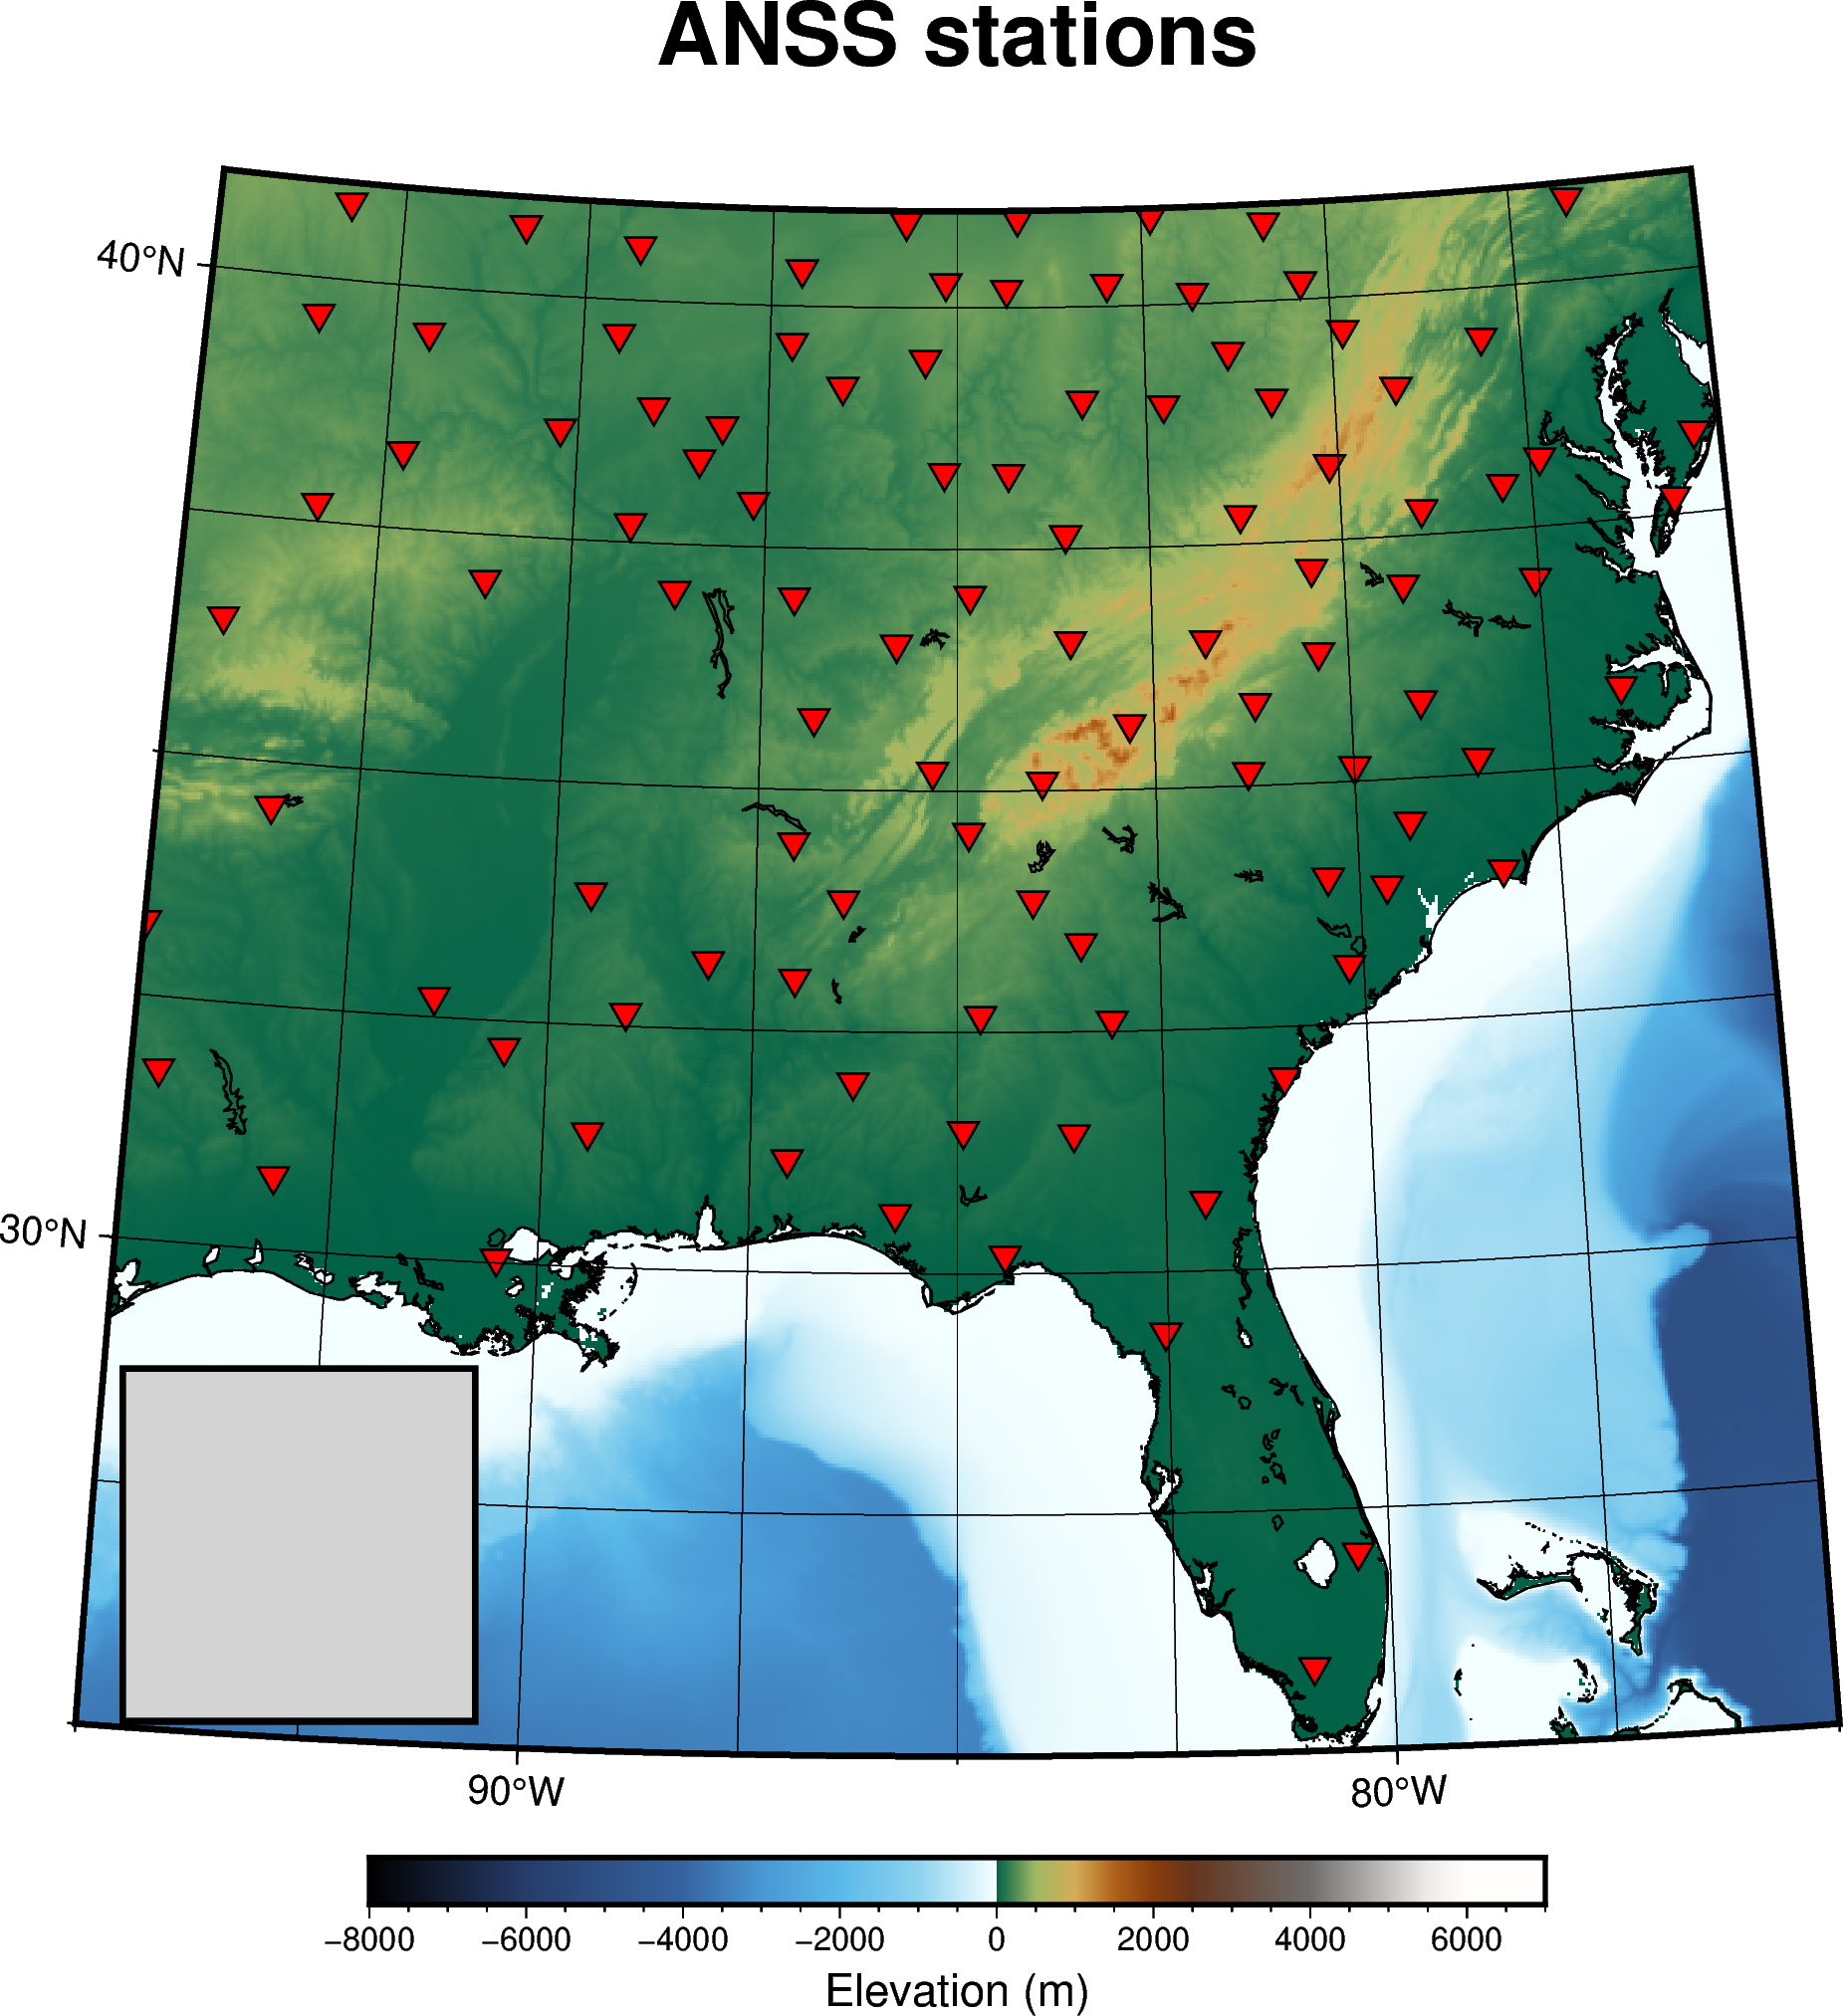

In [43]:
fig4 = pygmt.Figure()

fig4.grdimage(grid=grid, region=region, projection="T-85/33/15c", cmap="data/eleva.cpt")
fig4.coast(region=region, projection="T-85/33/15c", shorelines="0.5p,black")
fig4.plot(x=stations.longitude, y=stations.latitude, style="i0.3c", fill="red", pen="0.5p,black")
fig4.basemap(frame=["a10f5g2.5", '+tANSS stations'])
fig4.colorbar(cmap="data/eleva.cpt", frame="a2000f500+lElevation (m)", position="JBC+w10c/0.4c+mc+h",)


with fig4.inset(position=Position("BL", offset=(0.4, 0.3)),
                width=3, 
                box=Box(pen="black", fill="lightgrey")):
    pass

fig4.show()

For our example, it is convenient to add an inset map identifying the location of our studied area. For this, we will use the `fig.coast()` method to plot an orthographic map projection (`projection` = **G-85/35**) of the Americas (`region` = **g**). We will add a 2-point red box (**2p,red**) using the `fig.plot()` method. In this case, the attribute `style = 'r+s'` is used to identify a rectangle (**r**) defined by **[xmin, ymin, xmax, ymax]** coordinates. Note: `+s` is a modifier for "split status" or "opposite corners", instead of the standard [longitude, latitude, width, height]:

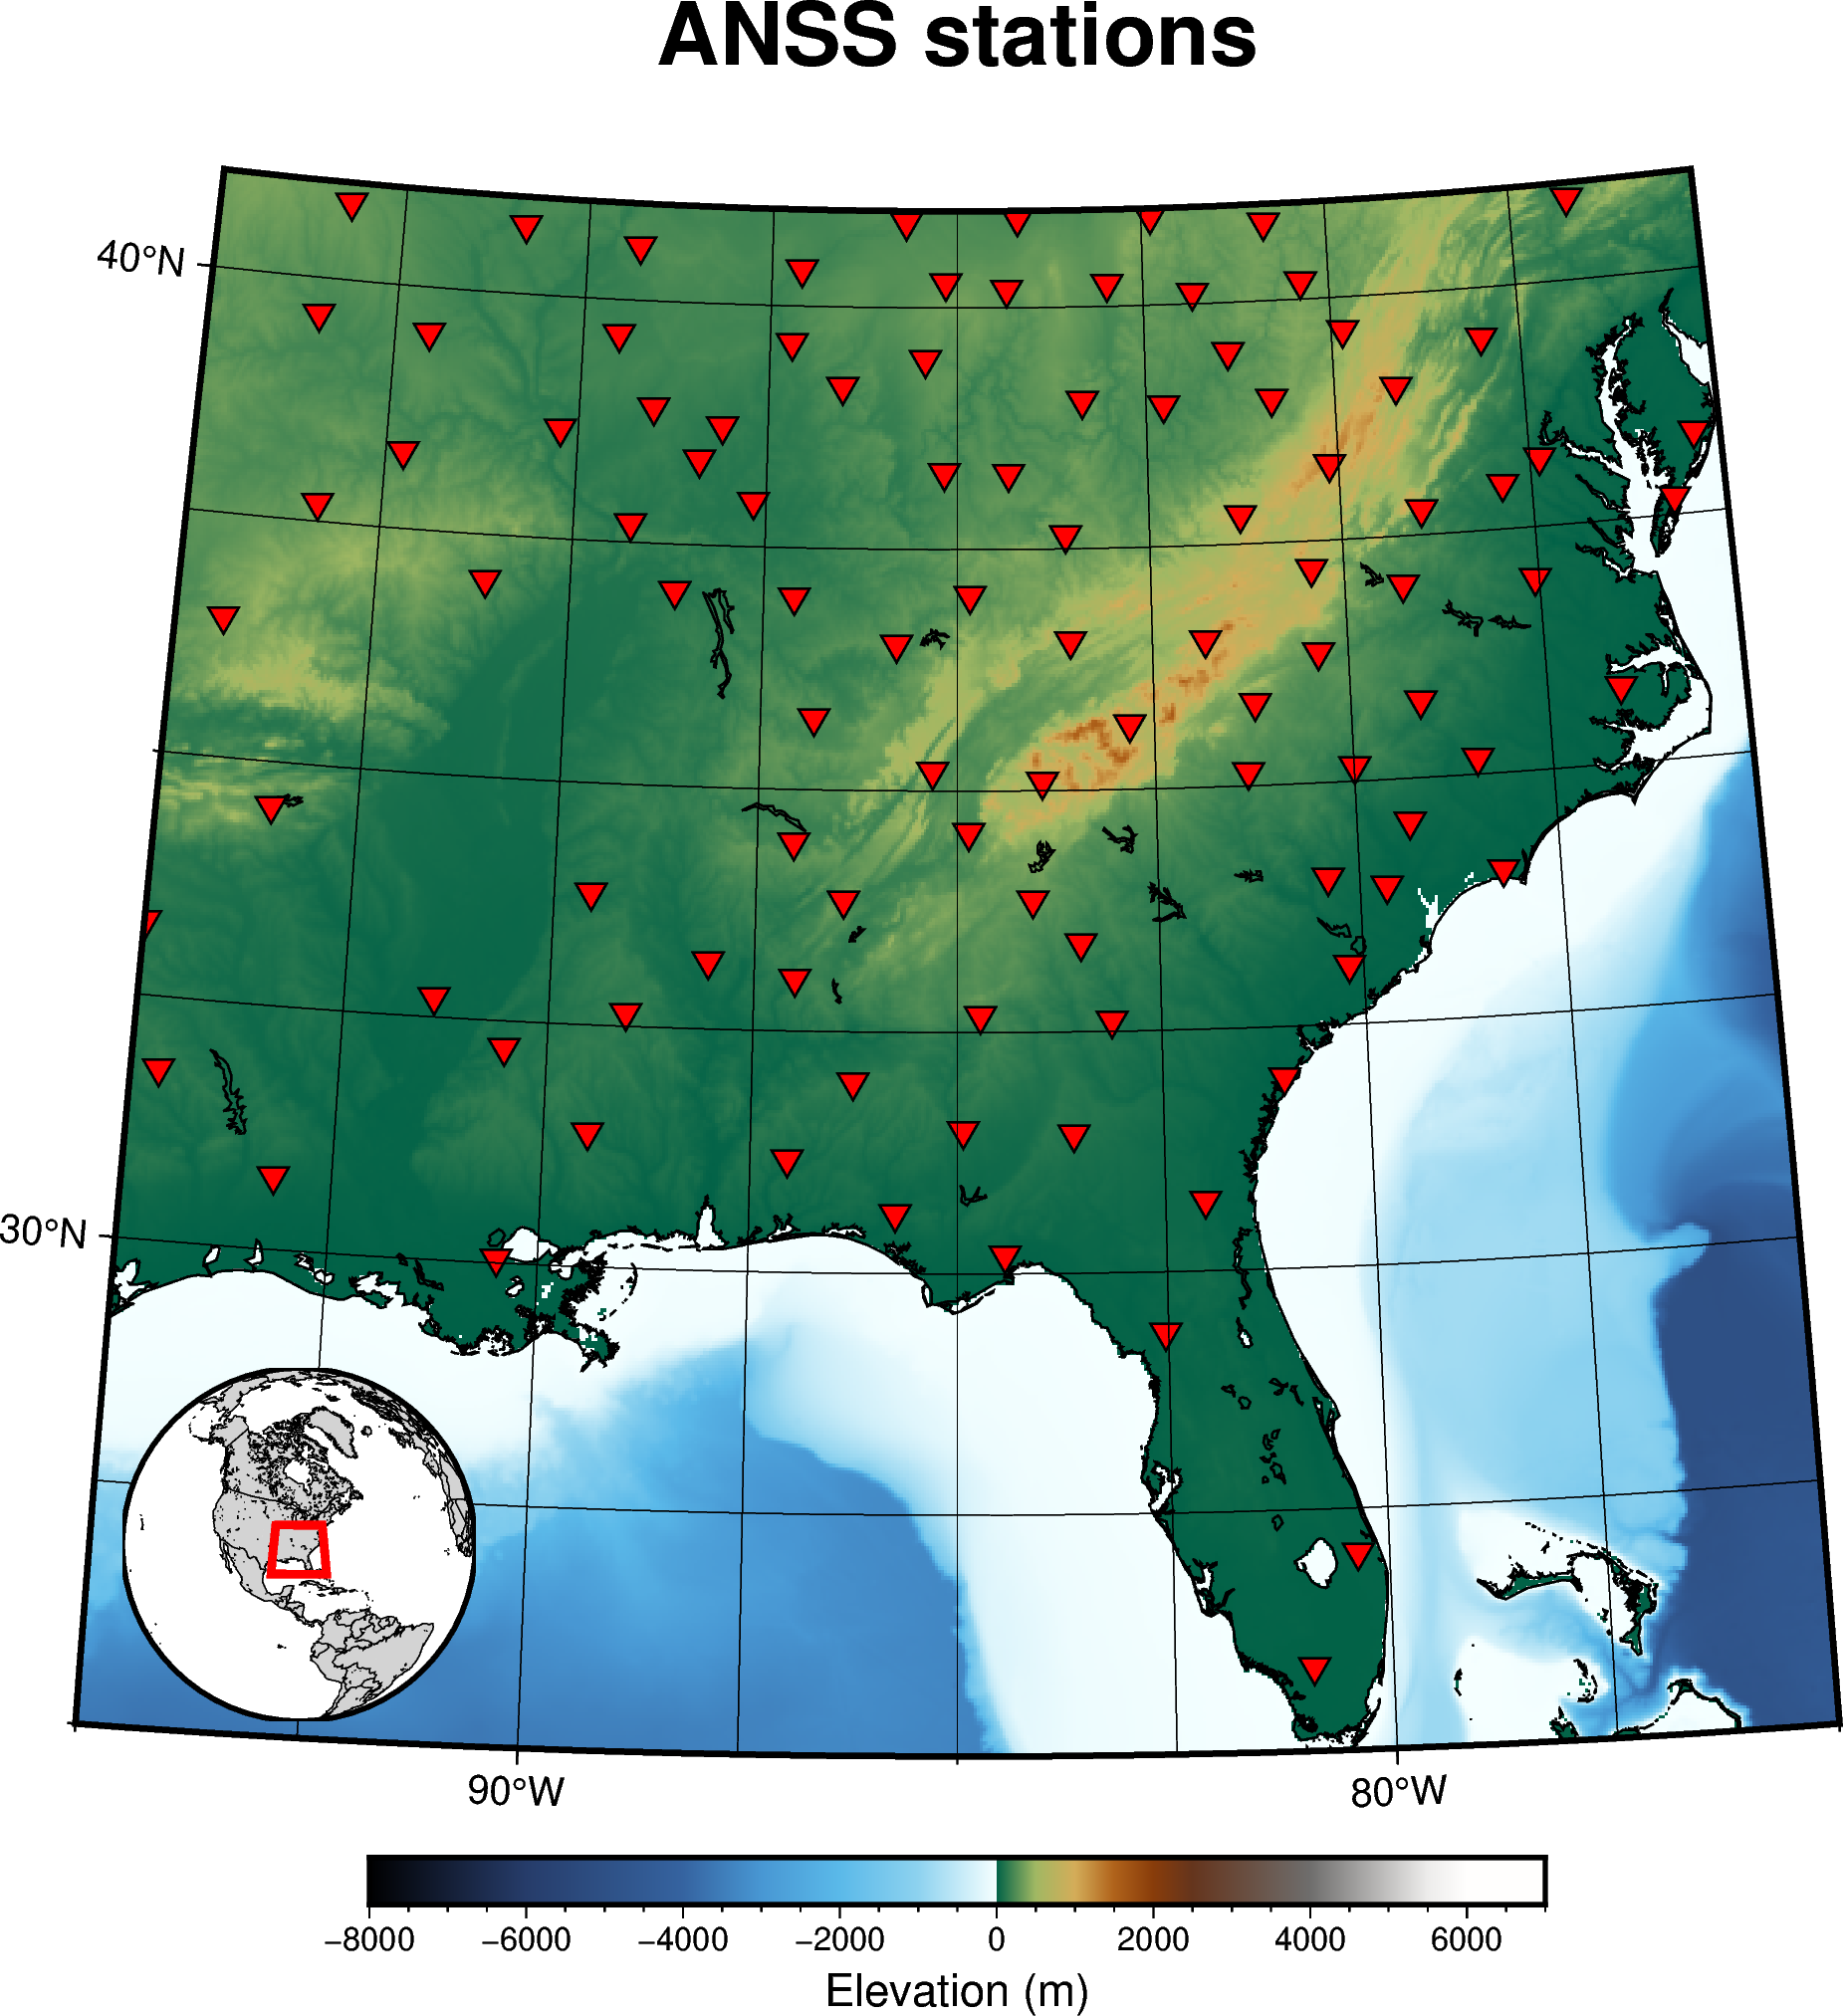

In [44]:
fig4 = pygmt.Figure()

fig4.grdimage(grid=grid, region=region, projection="T-85/33/15c", cmap="data/eleva.cpt")
fig4.coast(region=region, projection="T-85/33/15c", shorelines="0.5p,black")
fig4.plot(x=stations.longitude, y=stations.latitude, style="i0.3c", fill="red", pen="0.5p,black")
fig4.basemap(frame=["a10f5g2.5", '+tANSS stations'])
fig4.colorbar(cmap="data/eleva.cpt", frame="a2000f500+lElevation (m)", position="JBC+w10c/0.4c+mc+h",)


with fig4.inset(position=Position("BL", offset=(0.4, 0.3)), width=3):
      #  box=Box(pen="black")):   
     fig4.coast(
        region="g",
        projection="G-85/35/?",   
        land="lightgray",
        borders=1,
        shorelines=True,
        water="white"
    )
     fig4.basemap(frame="p")
     rectangle = [[region[0], region[2], region[1], region[3]]]
     fig4.plot(data=rectangle, style="r+s", pen="2p,red")

fig4.savefig('fig/ANSS_stations_CEUS.png',  transparent=True, dpi=300)
fig4.show()

## 2.4. Subplots

To create subplots, we need to define a layout with the `fig.suplot()` method. This is called using a `with` statement. For the layout, we need to define:

- `nrows`: Number of vertical rows.
- `ncols`: Number of horizontal columns
- `figsize` or `subsize`: Figure dimensiones, *e.g.*, [width, height]

To set each plot we used the `fig.set_panel()` method, identifing the subplot panel using the attribute `panel`, *e.g.,* index or [row, col]:

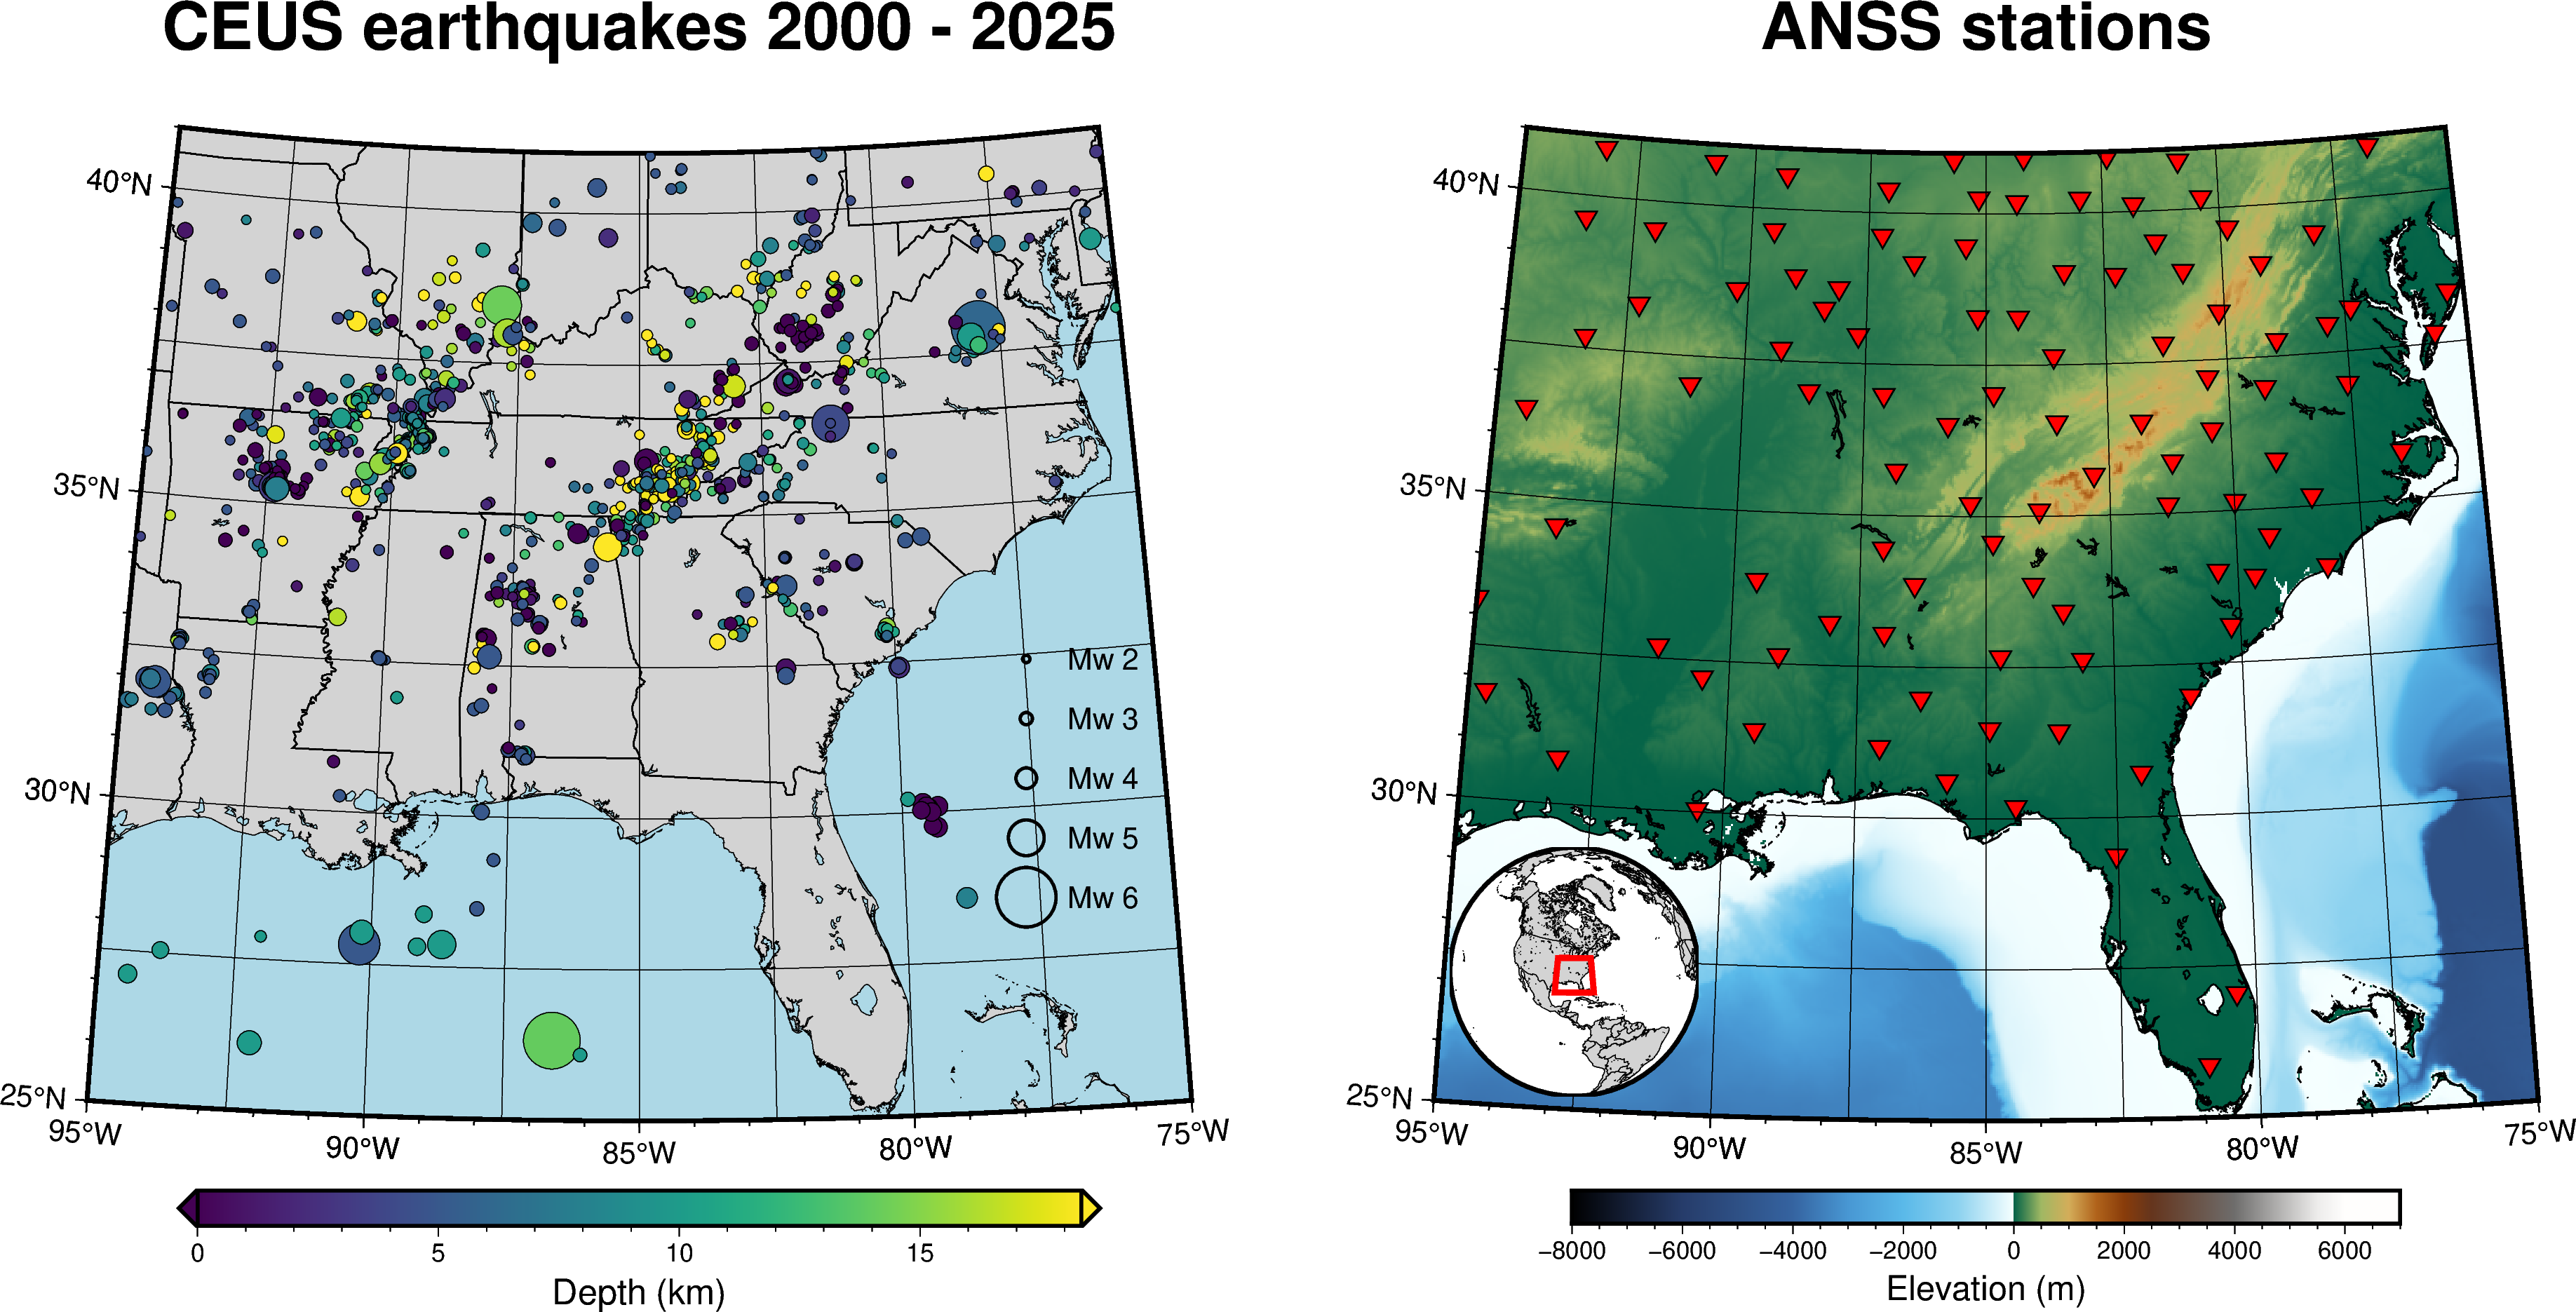

In [45]:
fig5 = pygmt.Figure()

with fig5.subplot(nrows=1, ncols=2, figsize=["30c", "12c"], margins = "1c"):

    with fig5.set_panel(panel=0):

        fig5.coast(region=region, projection="T-85/33/?", water="lightblue", land="lightgrey", borders="2/0.5p,black", shorelines=True)
        fig5.basemap(frame=["a10f5g2.5",'+tCEUS earthquakes 2000 - 2025'])

        vmin = data.depth.quantile(0.01)
        vmax = data.depth.quantile(0.99)

        pygmt.makecpt(
            cmap="matplotlib/viridis", series=[vmin, vmax], 
            background=True
        )

        fig5.plot(x=data.longitude,y=data.latitude, size=0.03 * 1.7**data.mag, fill=data.depth, cmap=True, style="c", pen="black")

        fig5.colorbar(frame="a5f1+lDepth (km)", bg_triangle=True, fg_triangle=True)  

        magnitudes = [2, 3, 4, 5, 6]
        legend = io.StringIO(
            #A symbol (S) type circle (c) with an horizontal offset of 0.5 cm, size 0.03*1.7^m without fill (-) and 1 point borderline.
            #Follow by a text of width 1 cm 
            "\n".join(f"S 0.5 c {0.03 * 1.7**m:.2f} - 1p 1 Mw {m}" for m in [2, 3, 4, 5, 6])  
        )
        fig5.legend(spec=legend, position=Position("BR", offset=[0.7,2.2]), line_spacing=2.0)

    with fig5.set_panel(panel=1):

        fig5.grdimage(grid=grid, region=region, projection="T-85/33/?", cmap="data/eleva.cpt")
        fig5.coast(region=region, projection="T-85/33/?", shorelines="0.5p,black")
        fig5.plot(x=stations.longitude, y=stations.latitude, style="i0.3c", fill="red", pen="0.5p,black")
        fig5.basemap(frame=["a10f5g2.5", '+tANSS stations'])
        fig5.colorbar(cmap="data/eleva.cpt", frame="a2000f500+lElevation (m)", position="JBC+w10c/0.4c+mc+h",)


        with fig5.inset(position=Position("BL", offset=(0.4, 0.3)), width=3):  
            fig5.coast(region="g", projection="G-85/35/?", land="lightgray", borders=1, shorelines=True, water="white")
            fig5.basemap(frame="p")
            rectangle = [[region[0], region[2], region[1], region[3]]]
            fig5.plot(data=rectangle, style="r+s", pen="2p,red")

fig5.savefig('fig/ANSS_stations_and_eqks_CEUS.png',  transparent=True, dpi=300)
fig5.show(width=1200)

## 2.5. GEOJSON format and focal mechanisms: Earthquakes $M_W$ 7.5 or higher from january 2025 to june 2026 

In this example, we will plot the tectonic plate boundaries and the focal mechanisms of events with $M_W$ 7.5 or higher recorded from 2025/01/01 to 2026/06/30. A set of major tectonic plate boundaries is provided by the USGS through its [Earthquake Hazard Program](https://www.usgs.gov/programs/earthquake-hazards/google-earthtmkml-files). For a comprehensive dataset of plate boundaries, refer to [Bird (2003)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2001gc000252). A parsed and clean version of Bird's dataset can be found at https://github.com/fraxen/tectonicplates/tree/master.

The tectonic plate boundaries are saved at **data/plate_boundaries** using a special file format: 

- [**GEOJSON**](https://datatracker.ietf.org/doc/html/rfc7946). A geospatial data format based on JavaScript Object Notation (JSON), a lightweight format for storing and transporting structured information. 

We can explore it using text editors (*e.g.*, VS Code, Notepad, TextEdit, or XCode), browser viewers (*e.g.*, Chrome or Firefox), or built-in Python libraries ([`json`](https://docs.python.org/3/library/json.html)). 

For the convergent boundaries, we have:




In [46]:
import json

with open('data/plate_boundaries/convergent_boundary.geojson', 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=3)) # 'indent=3' makes it easier to read


{
   "type": "FeatureCollection",
   "name": "convergent_boundary",
   "crs": {
      "type": "name",
      "properties": {
         "name": "urn:ogc:def:crs:OGC:1.3:CRS84"
      }
   },
   "features": [
      {
         "type": "Feature",
         "properties": {
            "Name": "North American:Pacific",
            "Description": "<html xmlns:fo=\"http://www.w3.org/1999/XSL/Format\" xmlns:msxsl=\"urn:schemas-microsoft-com:xslt\">\n<head>\n<META http-equiv=\"Content-Type\" content=\"text/html\">\n<meta http-equiv=\"content-type\" content=\"text/html; charset=UTF-8\">\n</head>\n<body style=\"margin:0px 0px 0px 0px;overflow:auto;background:#FFFFFF;\">\n<table style=\"font-family:Arial,Verdana,Times;font-size:12px;text-align:left;width:100%;border-collapse:collapse;padding:3px 3px 3px 3px\">\n<tr style=\"text-align:center;font-weight:bold;background:#9CBCE2\">\n<td>North American:Pacific</td>\n</tr>\n<tr>\n<td>\n<table style=\"font-family:Arial,Verdana,Times;font-size:12px;text-align

**pyGMT** does not natively interpret raw **GEOJSON** text strings within its plotting functions. Thus, we will use the [**geopandas**](https://geopandas.org/en/stable/docs.html) library to read and convert them into a structured `GeoDataFrame`. To install **geopandas** using conda:


<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">conda install -c conda-forge geopandas</code><br>
  </div>
</div>

We can read a **GEOJSON** file using the `gpd.read_file()` method. The data is loaded as a `GeoDataFrame`, a subclass of a `pandas.DataFrame` with a special column called **geometry** to store geometric shapes. For our example, we have four independent **GEOJSON** files for convergent, divergent, transform, and *other* (boundaries with complicated geological structures not well defined) types of tectonic plate boundaries:

In [47]:
import geopandas as gpd

conv_boundary = gpd.read_file("data/plate_boundaries/convergent_boundary.geojson")
div_boundary = gpd.read_file("data/plate_boundaries/divergent_boundary.geojson")
tran_boundary = gpd.read_file("data/plate_boundaries/transform_boundary.geojson")
other_boundary = gpd.read_file("data/plate_boundaries/other.geojson")

print(conv_boundary)

                          Name  \
0       North American:Pacific   
1       North American:Pacific   
2       North American:Pacific   
3       North American:Pacific   
4   North America:Juan de Fuca   
..                         ...   
58            Eurasian:Arabian   
59              Africa:Eurasia   
60              Africa:Eurasia   
61              Africa:Eurasia   
62                     Eurasia   

                                          Description                LABEL  \
0   <html xmlns:fo="http://www.w3.org/1999/XSL/For...  Convergent Boundary   
1   <html xmlns:fo="http://www.w3.org/1999/XSL/For...  Convergent Boundary   
2   <html xmlns:fo="http://www.w3.org/1999/XSL/For...  Convergent Boundary   
3   <html xmlns:fo="http://www.w3.org/1999/XSL/For...  Convergent Boundary   
4   <html xmlns:fo="http://www.w3.org/1999/XSL/For...  Convergent Boundary   
..                                                ...                  ...   
58  <html xmlns:fo="http://www.w3.org/1999/XS

We can pass a `GeoDataFrame` directly into **pyGMT** as a **data** attribute in the `fig.plot()` method. **pyGMT** automatically extracts the geometries and renders them using the map projection. 

For our example, we will use a [Ronbison projection](https://www.pygmt.org/v0.13.0/projections/misc/misc_robinson.html#sphx-glr-projections-misc-misc-robinson-py) (code: **N**). The fault lines will be drawn using conventional fault symbols with [**line fronts**](https://www.pygmt.org/v0.4.1/gallery/lines/linefronts.html). To do this, we will use the attribute `style` of the `fig.plot()` method:

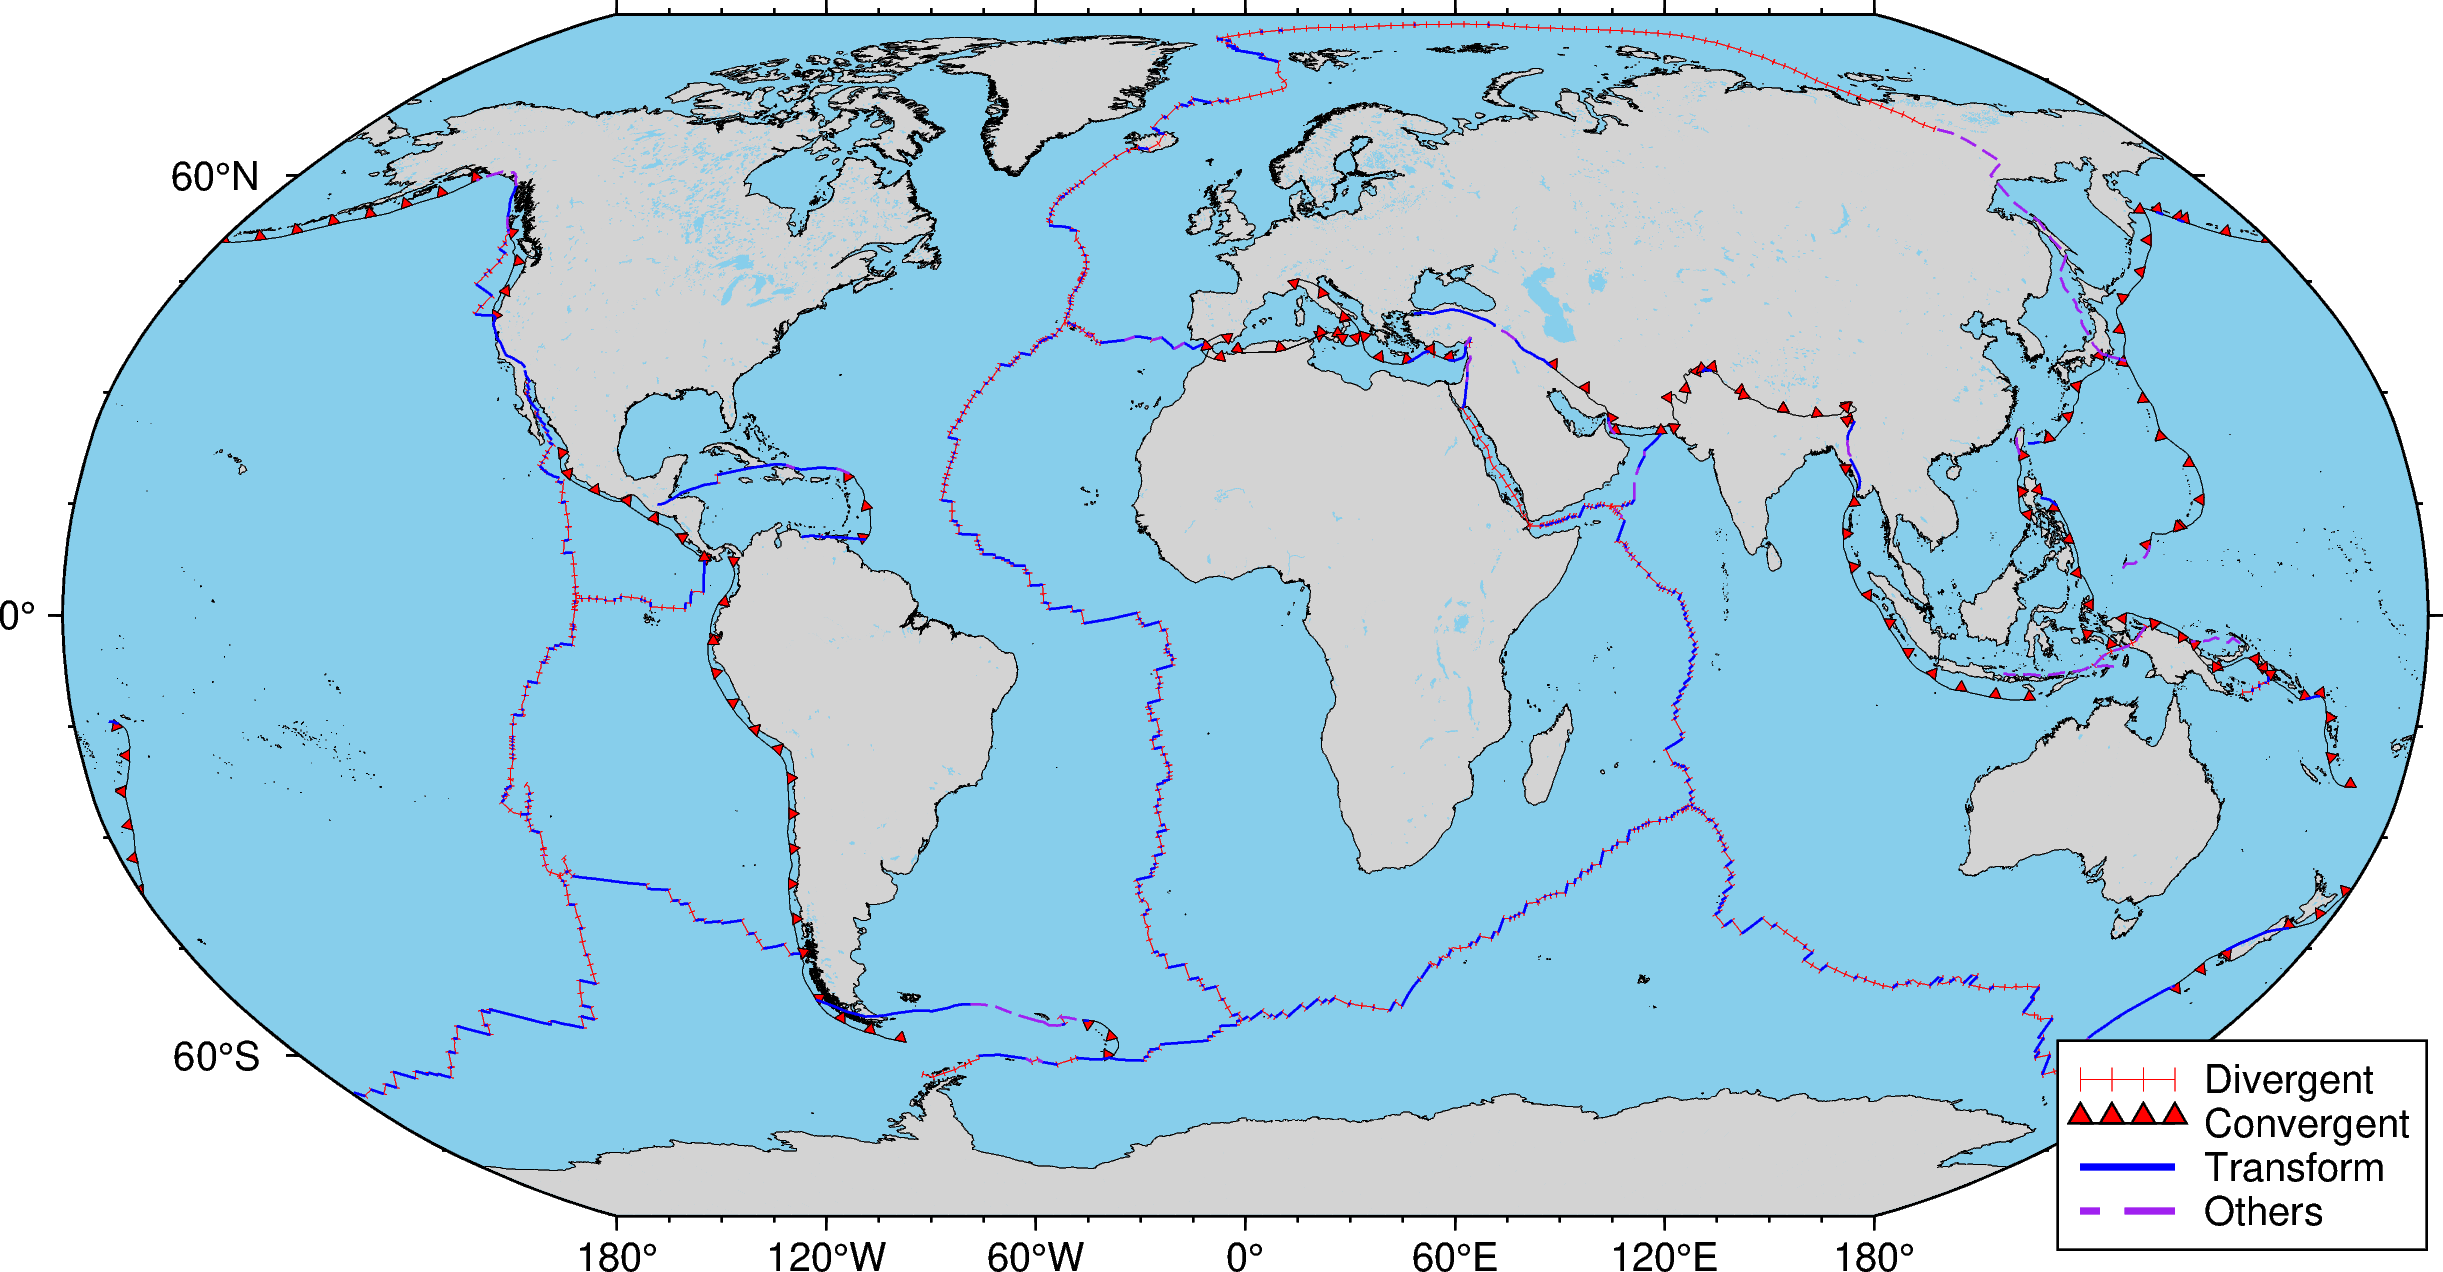

In [48]:
fig6 = pygmt.Figure()

# Create a global Robinson projection map
fig6.basemap(region="d", projection="N20c", frame=["af", "WSne"])
fig6.coast(resolution="i",shorelines="1/0.1p,black", land="lightgray", water="skyblue") # "i" indicates an intermediate resolution

# Divergent boundaries
fig6.plot(data=div_boundary, 
         style="f0.1c/0.05c+f", # f indicates a front with 0.1cm gap spacing and 0.05cm faults (+f)
         pen="0.1p,red")
# Convergent (subduction) boundaries
fig6.plot(data=conv_boundary,
        style="f0.3c/0.1c+t+r",  # f indicates a front with 0.3cm gap spacing and 0.3cm triangles (+t) pointing right (+r)
        fill="red",  # Fills the triangles with a red shade
        pen="0.1p,black") 

# Transform boundaries
fig6.plot(data=tran_boundary, pen="0.5p,blue")
# Other boundaries
fig6.plot(data=other_boundary, pen="0.5p,purple,dashed")

# Legend
leg_text = io.StringIO(
"""
N 1
S 0.45c f+f 0.8c/0.3/0.2c red 0.1p,red 1.1c Divergent
S 0.45c f+t+l 0.8c/0.3/0.2c red 0.4p,black 1.1c Convergent
S 0.45c - 0.8c - 1.5p,blue 1.1c Transform
S 0.45c - 0.8c - 1.5p,purple,dashed 1.1c Others
"""
)

fig6.legend(spec=leg_text, position="JBR+jBR+o0c/-0.3c",box="+gwhite+p0.5p")
fig6.show()

To describe the geometry of a fault, seismologists often assume a planar surface across which slip occurred during an earthquake. A `focal mechanism` describes the **fault orientation (strike and dip)** and the **slip direction (rake)** of the earthquake. The focal mechanisms are represented graphically using the so-called `"beachball" diagrams`. The beachballs are lower-hemisphere stereographic projections of the fault geometry. They consist of **circles with shadings indicating the direction of initial movement around the focus**, with darker-shaded quadrants indicating motion toward those quadrants (compression) and the lighter-shaded quadrants indicating motion away from those quadrants (dilatation):

<img src="https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/styles/full_width/public/media/images/Focal_mechanism_01.jpg?itok=6yL017ZA" width="600"/>



The focal mechanisms for normal,reverse/thrust, and strike-slip faults are:

<img src="https://earthjay.com/earthquakes/mechanism_legend_20230719.jpg" width="600"/>

Since most earthquakes are not pure normal, reverse/thrust, or strike-slip, their focal mechanisms are more complex. More details about focal mechanisms can be found at [IRIS](https://www.youtube.com/watch?v=MomVOkyDdLo) or [USGS](https://www.usgs.gov/observatories/yvo/news/earthquake-focal-mechanisms-lifes-a-beachball).

<img src="https://johnmilsom.online/wp-content/uploads/2021/02/kaverina-mod-1080x1270.jpg" width="400">

USGS provides focal mechanisms for individual earthquakes listed in the ComCat. You can find them at the **moment tensor** section of the **event page**, **e.g.,** [$M_W$ 5.8 Mineral, Virginia earthquake](https://earthquake.usgs.gov/earthquakes/eventpage/se609212/moment-tensor).

Focal mechanisms can be plotted using the `pygmt.Figure.meca()` method. The required attributes are: 

- `spec`: data (`numpy.array` or `pandas.DataFrame`) with the focal mechanism parameters (`strike`, `dip`, `rake`, and `magnitude`). 
- `scale`: radius of the beachball for a $M_W$ 5 (beachball size are proportional to $M_W$)    
- `longtidue`/`latitude`: Location of the event 

Optional arguments include:

- `event_name`: event's label
- `depth`: hypocentral depth
- `label_box`: draw a box behind the label given in `event_name`
- `plot_longitude`/`plot_latitude`: Longitude and latitude at which to place the beachball
- `offset`: properties of the line connecting the location of the event and the beachball

For our example, the events database has been downloaded from the [USGS Earthquake Catalog (ComCat)](https://earthquake.usgs.gov/earthquakes/search/) and is in **data/events_2025_2026.csv**. First, we will load the data as a `pandas.DataFrame`:

In [49]:
focal_mechanism = pd.read_csv("data/events_2025_2026.csv")
print(focal_mechanism)

                         event_name  longitude  latitude    depth  strike  \
0           Catia La Mar, Venezuela   -67.1935   10.6221   10.000  354.69   
1             Kablalan, Philippines   125.0560    5.5994   56.991  160.60   
2                     Neiafu, Tonga  -175.4763  -18.5387  234.000   24.84   
3                     Aomori, Japan   142.1836   40.9984   40.720  183.51   
4            Southern Drake Passage   -61.8164  -60.1875    5.639  194.06   
5  Petropavlovsk-Kamchatsky, Russia   160.7206   53.1426   27.000  214.02   
6                     Drake Passage   -61.9221  -60.3187   10.000  108.58   
7                 Kamchatka, Russia   160.2395   52.4948   35.000  198.47   
8                   Mandalay, Burma    95.9363   22.0110   10.000  269.87   
9       George Town, Cayman Islands   -82.3950   17.6506   14.326   78.20   

     dip    rake  magnitude  plot_longitude  plot_latitude  
0  85.74  -16.39        7.5             -55             20  
1  44.59   76.78        7.8   

Using our previous plot, we have: 

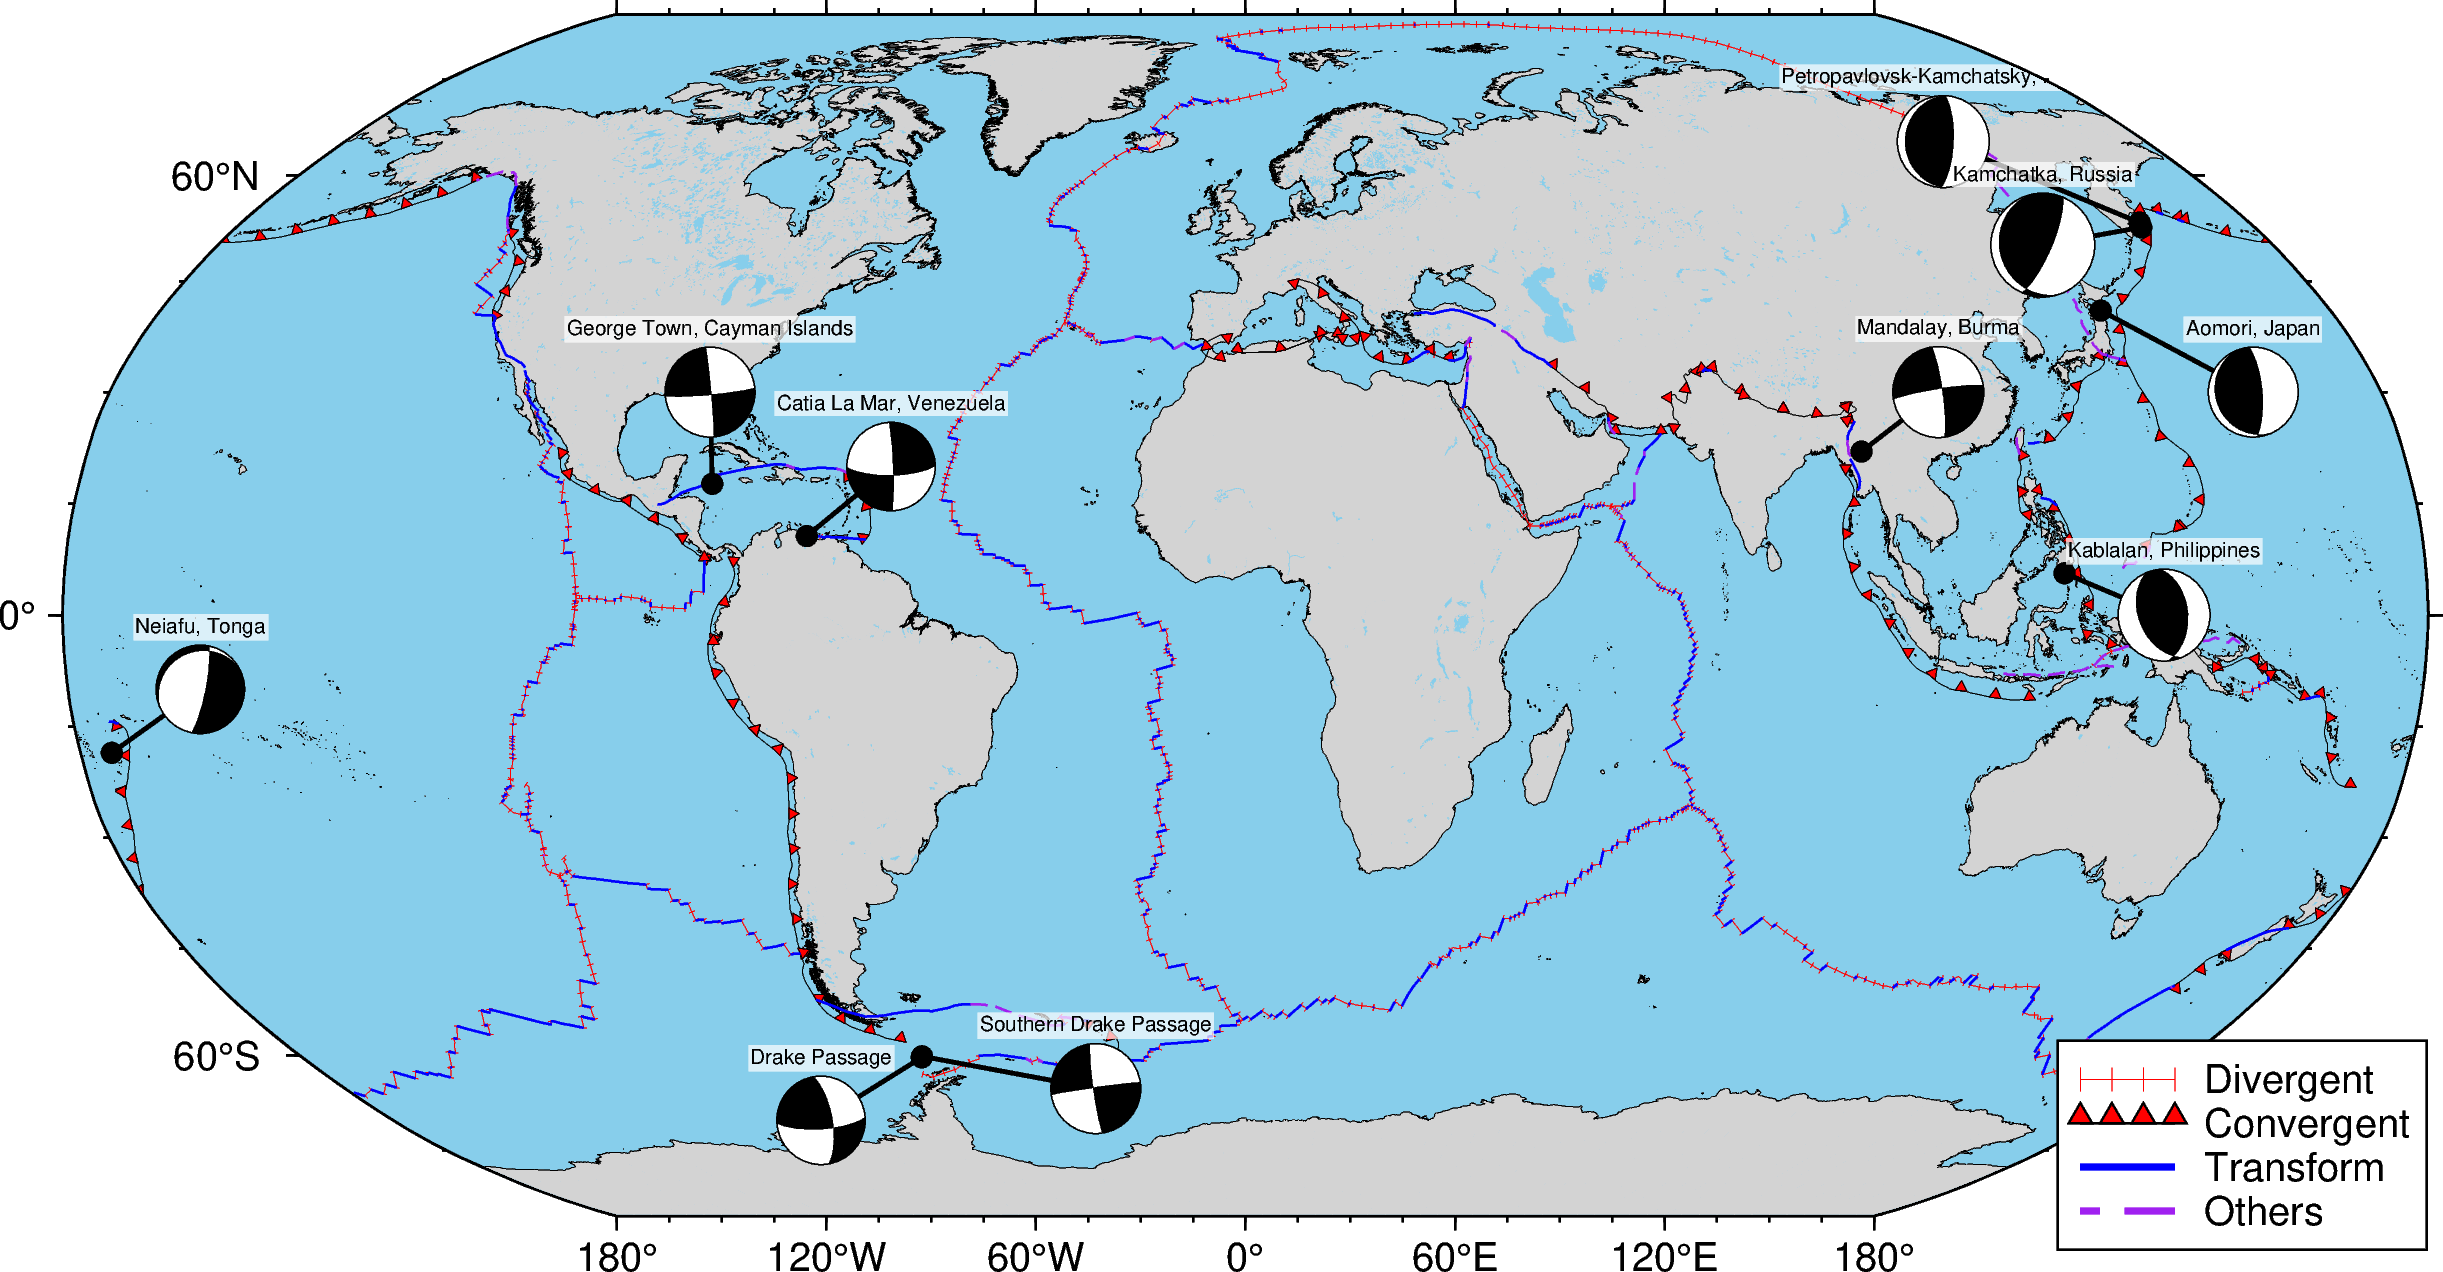

In [50]:
fig6.meca(spec=focal_mechanism, 
         scale="0.5c+f5p",              # +f5p indicates font size 5 points for the event_name
         label_box="white@30",          # white@30 provides a transparency of 30% to the label box
         offset="+p1p,black+s0.15c")

fig6.show()

<div class="alert alert-block alert-info">
<b>Question:</b> What patterns can you recognize between the type of faulting and the focal mechanisms of these events?
</div>

We can color our beachballs by `depth`. For that, we pass a **cmap** indicating the desired colormap:

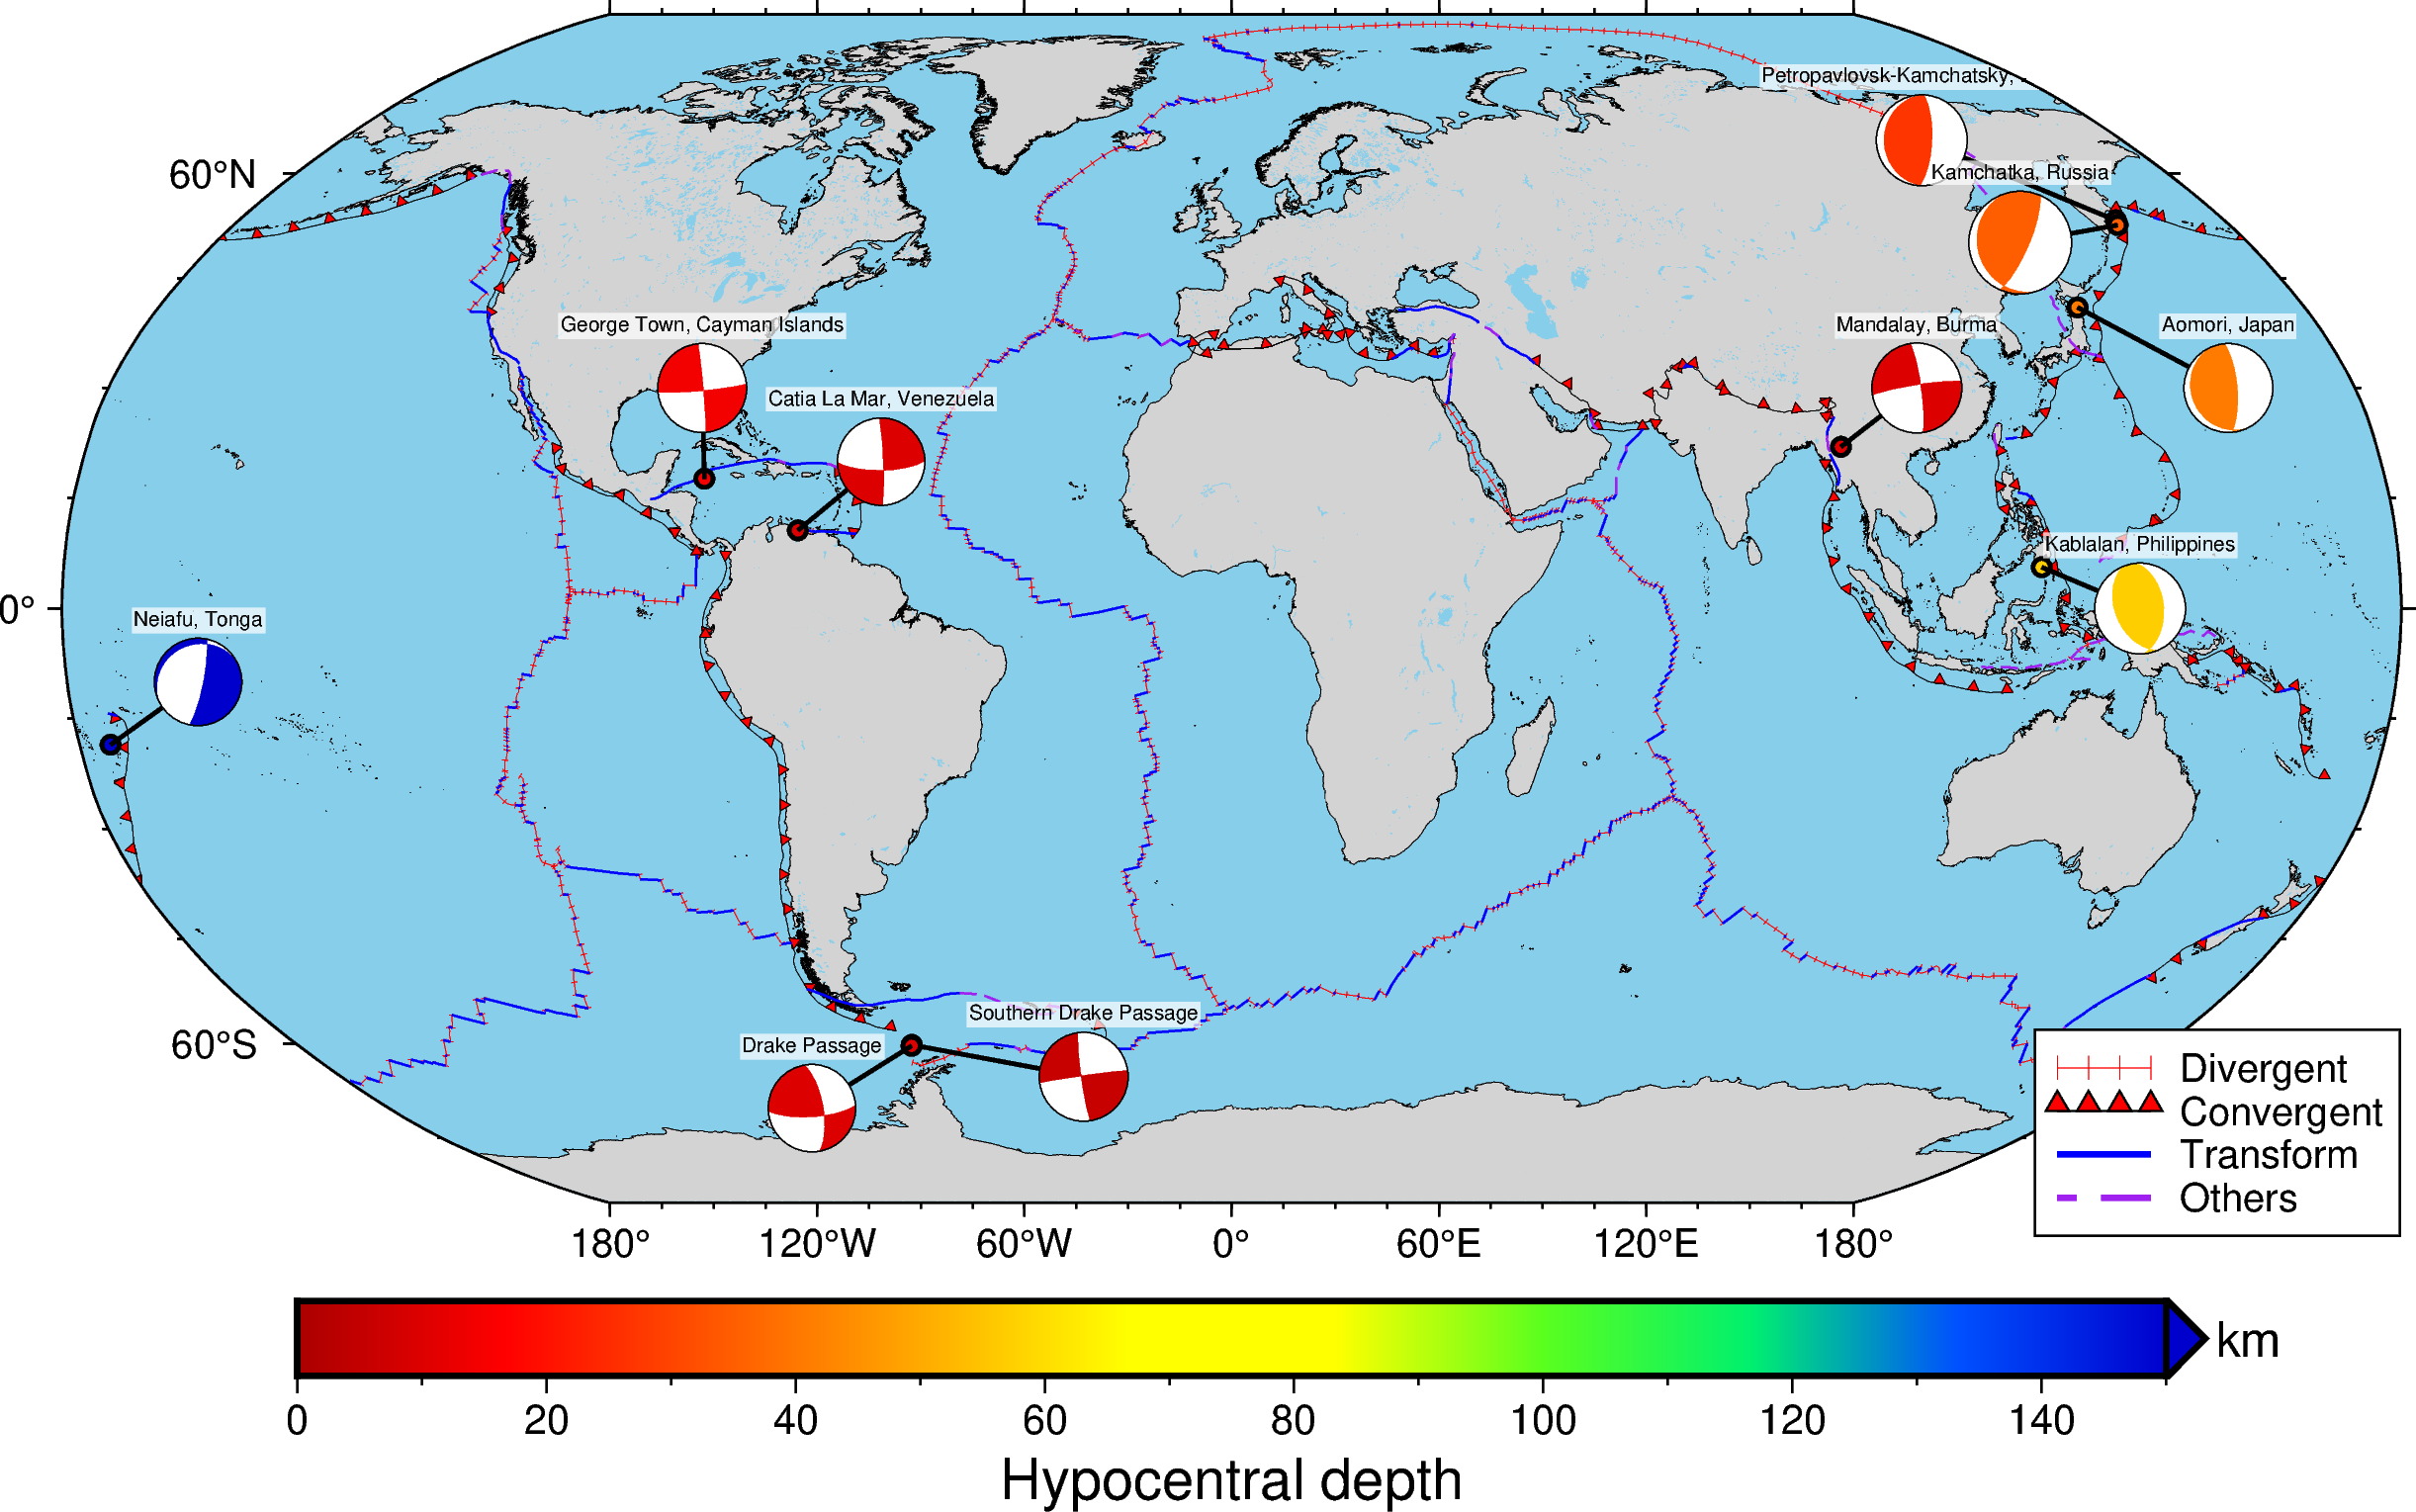

In [51]:
fig6 = pygmt.Figure()

fig6.basemap(region="d", projection="N20c", frame=["af", "WSne"])
fig6.coast(resolution="i",shorelines="1/0.1p,black", land="lightgray", water="skyblue") # "i" indicates an intermediate resolution

fig6.plot(data=div_boundary, style="f0.1c/0.05c+f", pen="0.1p,red")
fig6.plot(data=conv_boundary, style="f0.3c/0.1c+t+r", fill="red", pen="0.1p,black") 
fig6.plot(data=tran_boundary, pen="0.5p,blue")
fig6.plot(data=other_boundary, pen="0.5p,purple,dashed")

# Legend
leg_text = io.StringIO(
"""
N 1
S 0.45c f+f 0.8c/0.3/0.2c red 0.1p,red 1.1c Divergent
S 0.45c f+t+l 0.8c/0.3/0.2c red 0.4p,black 1.1c Convergent
S 0.45c - 0.8c - 1.5p,blue 1.1c Transform
S 0.45c - 0.8c - 1.5p,purple,dashed 1.1c Others
"""
)

fig6.legend(spec=leg_text, position="JBR+jBR+o0c/-0.3c",box="+gwhite+p0.5p")

pygmt.makecpt(cmap="gmt/seis", series=[0, 150], background=True)
fig6.colorbar(label="Hypocentral depth", unit="km", fg_triangle=True)

fig6.meca(spec=focal_mechanism, 
         scale="0.5c+f5p",
         label_box="white@30", 
         cmap=True,
         offset="+p1p,black+s0.15c")

fig6.savefig('fig/events_Mw7_5_2025_2026.png',  transparent=True, dpi=300)
fig6.show()